<a href="https://colab.research.google.com/github/Uma-Maheswari298/Global-Weather-Air-Quality-Analytics/blob/main/Global_Weather_%26_Air_Quality_Analysiss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Stage 1

## **Global Weather & Air Quality Analysis (2024-2026) using Python**

##Dataset Information
**Source:**  World data foundation.org

**Dataset Link:** https://worlddatafoundation.org/datasets

**Dataset:**  Global Weather & Air Quality Data

**Location:** Global(Multiple Countries & Cities)

**Format:** CSV

**Domain:** Weather

**Timeline:** 2024 - 2026

## Project Overview

Global Weather & Air Quality Analytics is a Python-based data analytics project that analyzes weather conditions and air quality data across multiple countries and cities.

## Problem Defenition
- The  problem is to understand how weather conditions and air quality vary across different locations and weather parameters have any relationship with air polution.
- This project uses Python based data analysis ti identify these patterns aand provide meaningful insights.

## Objectives
•  To analyze the distribution and variability of temperature across the dataset.

•  To identify and visualize the most frequently occurring weather conditions in the dataset.

•  To analyze global weather conditions across different countries.

•  To identify relationships between weather parameters and air quality indicators using correlation analysis.

•  To analyze the relationship between actual temperature and feels-like temperature.

•  To identify locations with higher pollution levels using air quality indicators and pollution categories.

•  To analyze the monthly distribution and variation of pollution categories.

•  To examine the relationship between temperature and PM2.5 levels across different pollution categories.

•  To identify hourly patterns in PM2.5 and PM10 pollution levels.


## Tools Used
 Python
- Pandas - Data cleaning & manipulation
- NumPy - Numerical analysis
- Matplotlib - Data visualization
- Seaborn - Statistical visualization

In [1]:
## Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Dataset Upload
- The CSV file could not be uploaded to GitHub due to its large file size. Therfore, it was uploaded to Google Drive and accessed through Google Colab for further analysis

In [2]:
# Data Ingestion from Google Drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
## Load the Dataset

df = pd.read_csv("/content/drive/MyDrive/Python Capstone Poject/Global Weather & Air Quality Analytics Raw Data.csv")
df

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,16-05-2024 13:15,26.6,79.8,Partly Cloudy,...,8.40,26.60,1,1,4:50 AM,6:50 PM,12:12 PM,1:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,16-05-2024 10:45,19.0,66.2,Partly cloudy,...,1.10,2.00,1,1,5:21 AM,7:54 PM,12:58 PM,2:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,16-05-2024 09:45,23.0,73.4,Sunny,...,10.40,18.40,1,1,5:40 AM,7:50 PM,1:15 PM,2:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,16-05-2024 10:45,6.3,43.3,Light drizzle,...,0.70,0.90,1,1,6:31 AM,9:11 PM,2:12 PM,3:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,16-05-2024 09:45,26.0,78.8,Partly cloudy,...,183.40,262.30,5,10,6:12 AM,5:55 PM,1:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125691,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1771742700,22-02-2026 02:45,25.0,77.0,Clear,...,3.55,4.35,1,1,6:45 AM,6:37 PM,10:23 AM,11:21 PM,Waxing Crescent,24
125692,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1771742700,22-02-2026 13:45,22.4,72.3,Mist,...,27.35,30.65,2,3,6:22 AM,5:58 PM,9:16 AM,10:38 PM,Waxing Crescent,20
125693,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1771742700,22-02-2026 09:45,13.2,55.7,Sunny,...,10.65,22.85,1,1,6:24 AM,6:09 PM,9:38 AM,10:46 PM,Waxing Crescent,22
125694,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1771742700,22-02-2026 08:45,18.6,65.5,Patchy rain nearby,...,1.85,1.85,1,1,6:05 AM,6:35 PM,10:24 AM,10:05 PM,Waxing Crescent,22


**Data Inspection**

In [4]:
## Make copy of Original Dataset

df_copy = df.copy()
df_copy

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,16-05-2024 13:15,26.6,79.8,Partly Cloudy,...,8.40,26.60,1,1,4:50 AM,6:50 PM,12:12 PM,1:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,16-05-2024 10:45,19.0,66.2,Partly cloudy,...,1.10,2.00,1,1,5:21 AM,7:54 PM,12:58 PM,2:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,16-05-2024 09:45,23.0,73.4,Sunny,...,10.40,18.40,1,1,5:40 AM,7:50 PM,1:15 PM,2:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,16-05-2024 10:45,6.3,43.3,Light drizzle,...,0.70,0.90,1,1,6:31 AM,9:11 PM,2:12 PM,3:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,16-05-2024 09:45,26.0,78.8,Partly cloudy,...,183.40,262.30,5,10,6:12 AM,5:55 PM,1:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125691,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1771742700,22-02-2026 02:45,25.0,77.0,Clear,...,3.55,4.35,1,1,6:45 AM,6:37 PM,10:23 AM,11:21 PM,Waxing Crescent,24
125692,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1771742700,22-02-2026 13:45,22.4,72.3,Mist,...,27.35,30.65,2,3,6:22 AM,5:58 PM,9:16 AM,10:38 PM,Waxing Crescent,20
125693,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1771742700,22-02-2026 09:45,13.2,55.7,Sunny,...,10.65,22.85,1,1,6:24 AM,6:09 PM,9:38 AM,10:46 PM,Waxing Crescent,22
125694,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1771742700,22-02-2026 08:45,18.6,65.5,Patchy rain nearby,...,1.85,1.85,1,1,6:05 AM,6:35 PM,10:24 AM,10:05 PM,Waxing Crescent,22


In [5]:
## Shows First 7 rows of Dataset
print("First 7 Rows")
df.head(7)

First 7 Rows


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,16-05-2024 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,4:50 AM,6:50 PM,12:12 PM,1:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,16-05-2024 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,5:21 AM,7:54 PM,12:58 PM,2:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,16-05-2024 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,5:40 AM,7:50 PM,1:15 PM,2:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,16-05-2024 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,6:31 AM,9:11 PM,2:12 PM,3:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,16-05-2024 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,6:12 AM,5:55 PM,1:17 PM,12:38 AM,Waxing Gibbous,55
5,Antigua and Barbuda,Saint John's,17.12,-61.85,America/Antigua,1715849100,16-05-2024 04:45,26.0,78.8,Partly cloudy,...,1.2,4.5,1,1,5:36 AM,6:32 PM,1:05 PM,1:14 AM,Waxing Gibbous,55
6,Argentina,Buenos Aires,-34.59,-58.67,America/Argentina/Buenos_Aires,1715849100,16-05-2024 05:45,8.0,46.4,Clear,...,4.0,5.3,1,1,7:43 AM,5:59 PM,2:36 PM,1:04 AM,Waxing Gibbous,55


In [6]:
print("Shows Last 5 Rows")
df.tail(5)

Shows Last 5 Rows


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
125691,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1771742700,22-02-2026 02:45,25.0,77.0,Clear,...,3.55,4.35,1,1,6:45 AM,6:37 PM,10:23 AM,11:21 PM,Waxing Crescent,24
125692,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1771742700,22-02-2026 13:45,22.4,72.3,Mist,...,27.35,30.65,2,3,6:22 AM,5:58 PM,9:16 AM,10:38 PM,Waxing Crescent,20
125693,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1771742700,22-02-2026 09:45,13.2,55.7,Sunny,...,10.65,22.85,1,1,6:24 AM,6:09 PM,9:38 AM,10:46 PM,Waxing Crescent,22
125694,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1771742700,22-02-2026 08:45,18.6,65.5,Patchy rain nearby,...,1.85,1.85,1,1,6:05 AM,6:35 PM,10:24 AM,10:05 PM,Waxing Crescent,22
125695,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1771742700,22-02-2026 08:45,17.6,63.6,Sunny,...,7.85,8.45,1,1,5:53 AM,6:26 PM,10:16 AM,9:50 PM,Waxing Crescent,22


In [ ]:
## Shape of Datset
print("Shape of Dataset")
df.shape

Shape of Dataset


(125696, 41)

In [7]:
# Show detailed info (data types, null values, memory usage)

print("Dataset Info")
df.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125696 entries, 0 to 125695
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       125696 non-null  object 
 1   location_name                 125696 non-null  object 
 2   latitude                      125696 non-null  float64
 3   longitude                     125696 non-null  float64
 4   timezone                      125696 non-null  object 
 5   last_updated_epoch            125696 non-null  int64  
 6   last_updated                  125696 non-null  object 
 7   temperature_celsius           125696 non-null  float64
 8   temperature_fahrenheit        125696 non-null  float64
 9   condition_text                125696 non-null  object 
 10  wind_mph                      125696 non-null  float64
 11  wind_kph                      125696 non-null  float64
 12  wind_degree                   1

In [8]:
## Retrieve the Column Names

print("Display Column Names")
df.columns

Display Column Names


Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [9]:
## Statistical Summary

print("Statistical Summary")
df.describe()

Statistical Summary


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,125696.000000,125696.000000,1.256960e+05,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,...,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.00000,125696.000000,125696.000000
mean,19.194568,21.991888,1.743818e+09,21.566100,70.820737,8.065337,12.983490,169.194485,1014.056151,29.944425,...,18.313417,475.238117,58.849519,15.233954,10.655142,24.566170,49.150925,1.70914,2.632009,49.305197
std,24.424871,65.793741,1.613528e+07,9.615498,17.307770,7.357052,11.836967,103.476980,10.590443,0.312697,...,13.993081,780.408684,31.095163,24.228717,36.852953,37.760634,151.532042,0.95001,2.471206,35.095182
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.00000,1.000000,0.000000
25%,3.750000,-6.836100,1.729848e+09,16.300000,61.300000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.400000,210.696500,39.000000,1.665000,1.050000,7.100000,10.000000,1.00000,1.000000,14.000000
50%,17.250000,23.240000,1.743844e+09,24.100000,75.400000,6.900000,11.200000,162.000000,1014.000000,29.930000,...,15.500000,302.850000,56.000000,5.500000,2.450000,14.245000,20.250000,1.00000,2.000000,49.000000
75%,40.400000,50.580000,1.757751e+09,28.100000,82.600000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.300000,471.750000,75.000000,17.760000,8.550000,28.120000,42.180000,2.00000,3.000000,84.000000
max,64.150000,179.220000,1.771743e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.00000,10.000000,100.000000


In [10]:
## Check Unique Values

cols = ["country", "condition_text", "wind_direction"]

for i in cols:
    print("Unique Values:", i)
    print(df[i].unique())

Unique Values: country
['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Madagascar' 'Cape Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Comoros' 'Congo'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czech Republic'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Swaziland' 'Ethiopia' 'Fiji Islands' 'Finland'
 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Vatican City'
 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq'
 'Ireland' 'Israel' 'Italy' 'Jamaica' 

## **Satge 2**

##Data Cleaning

**Remove unused Columns**

- The raw dataset initially contained 42 columns. Based on my project objectives, I selected the relevant weather and air quality features.
- I removed redundant columns with duplicate information in different units, technical timestamp fields, and less relevant moon-related and air quality index fields to keep the dataset focused and avoid redundancy.

In [11]:
cols = (['last_updated_epoch', 'temperature_fahrenheit', 'wind_mph',
        'pressure_in','precip_in', 'feels_like_fahrenheit',  'visibility_miles',
        'gust_mph', 'air_quality_Sulphur_dioxide','air_quality_gb-defra-index', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination','sunrise','sunset'])
df = df.drop(columns = cols)
df

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,16-05-2024 13:15,26.6,Partly Cloudy,13.3,338,...,25.3,10.0,7.0,15.3,277.00,103.0,1.10,8.40,26.60,1
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,16-05-2024 10:45,19.0,Partly cloudy,11.2,320,...,19.0,10.0,5.0,18.4,193.60,97.3,0.90,1.10,2.00,1
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,16-05-2024 09:45,23.0,Sunny,15.1,280,...,24.6,10.0,5.0,22.3,540.70,12.2,65.10,10.40,18.40,1
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,16-05-2024 10:45,6.3,Light drizzle,11.9,215,...,3.8,2.0,2.0,13.7,170.20,64.4,1.60,0.70,0.90,1
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,16-05-2024 09:45,26.0,Partly cloudy,13.0,150,...,28.7,10.0,8.0,20.2,2964.00,19.0,72.70,183.40,262.30,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125691,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,22-02-2026 02:45,25.0,Clear,6.5,156,...,27.9,10.0,0.0,13.6,274.85,51.0,4.85,3.55,4.35,1
125692,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,22-02-2026 13:45,22.4,Mist,10.4,122,...,24.7,5.0,1.2,14.0,516.85,39.0,25.85,27.35,30.65,2
125693,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,22-02-2026 09:45,13.2,Sunny,5.4,30,...,13.2,10.0,5.2,6.2,139.85,71.0,2.45,10.65,22.85,1
125694,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,22-02-2026 08:45,18.6,Patchy rain nearby,16.6,80,...,18.6,10.0,1.8,24.1,154.85,38.0,1.85,1.85,1.85,1


In [12]:
## After Removing unused columns
print("Shape of Dataset")
df.shape

Shape of Dataset


(125696, 25)

In [13]:
## Check Missing Values
print("Missing Values")
df.isnull().sum()

Missing Values


,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated,0
temperature_celsius,0
condition_text,0
wind_kph,0
wind_degree,0


- There are no missing values in the dataset, so no missing-value treatment or imputation was required.

In [14]:
## Check Duplicates

print("Duplicates in this Dataset")
df.duplicated().sum()

Duplicates in this Dataset


np.int64(1)

In [15]:
## After Remove unused columns display dataset

df.head(3)

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,16-05-2024 13:15,26.6,Partly Cloudy,13.3,338,...,25.3,10.0,7.0,15.3,277.0,103.0,1.1,8.4,26.6,1
1,Albania,Tirana,41.33,19.82,Europe/Tirane,16-05-2024 10:45,19.0,Partly cloudy,11.2,320,...,19.0,10.0,5.0,18.4,193.6,97.3,0.9,1.1,2.0,1
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,16-05-2024 09:45,23.0,Sunny,15.1,280,...,24.6,10.0,5.0,22.3,540.7,12.2,65.1,10.4,18.4,1


In [16]:
## After Remove unused columns display column names
print("Display Column Names")
df.columns

Display Column Names


Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index'],
      dtype='object')

**Statistical Summary**

In [17]:
## After Remove unused columns display Statistical summary
df.describe()

,latitude,longitude,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
count,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.000000,125696.00000
mean,19.194568,21.991888,21.566100,12.983490,169.194485,1014.056151,0.136669,66.178582,40.036517,22.455920,9.516103,3.430559,18.313417,475.238117,58.849519,15.233954,24.566170,49.150925,1.70914
std,24.424871,65.793741,9.615498,11.836967,103.476980,10.590443,0.570388,24.023978,34.087668,11.495981,2.674087,3.564159,13.993081,780.408684,31.095163,24.228717,37.760634,151.532042,0.95001
min,-41.300000,-175.200000,-29.800000,3.600000,1.000000,947.000000,0.000000,2.000000,0.000000,-36.700000,0.000000,0.000000,3.600000,-9999.000000,0.000000,0.000000,0.168000,-1848.150000,1.00000
25%,3.750000,-6.836100,16.300000,6.100000,80.000000,1010.000000,0.000000,50.000000,0.000000,16.300000,10.000000,0.100000,10.400000,210.696500,39.000000,1.665000,7.100000,10.000000,1.00000
50%,17.250000,23.240000,24.100000,11.200000,162.000000,1014.000000,0.000000,71.000000,31.000000,25.300000,10.000000,2.100000,15.500000,302.850000,56.000000,5.500000,14.245000,20.250000,1.00000
75%,40.400000,50.580000,28.100000,17.600000,256.000000,1018.000000,0.030000,85.000000,75.000000,30.100000,10.000000,6.000000,24.300000,471.750000,75.000000,17.760000,28.120000,42.180000,2.00000
max,64.150000,179.220000,49.200000,2963.200000,360.000000,3006.000000,42.240000,100.000000,100.000000,51.200000,32.000000,16.300000,2970.400000,38879.398000,480.700000,427.700000,1614.100000,6037.290000,6.00000


**Data Type Check**

In [18]:
## Check Datatypes

print("Data Type")
df.dtypes

Data Type


,0
country,object
location_name,object
latitude,float64
longitude,float64
timezone,object
last_updated,object
temperature_celsius,float64
condition_text,object
wind_kph,float64
wind_degree,int64


**Country Column**

In [19]:
## Check Country Column unique Values

print(f"\n Number of Unique Values : {df["country"].nunique()}")
print(f"\n Unique Values: {df["country"].unique()}")


 Number of Unique Values : 211

 Unique Values: ['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Madagascar' 'Cape Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Comoros' 'Congo'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czech Republic'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Swaziland' 'Ethiopia' 'Fiji Islands' 'Finland'
 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Vatican City'
 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq'
 'Ireland' '

- I found that some country names were represented using different languages, spellings.
- I standardized these country names into consistent  names using a mapping dictionary to ensure accurate grouping and country-wise analysis.

In [20]:
country_mapping = {
    'Malásia': 'Malaysia',
    'Komoren': 'Comoros',
    'كولومبيا': 'Colombia',
    'Estonie': 'Estonia',
    'Гватемала': 'Guatemala',
    'Inde': 'India',
    'Letonia': 'Latvia',
    'Польша': 'Poland',
    'Mexique': 'Mexico',
    'Polônia': 'Poland',
    'Marrocos': 'Morocco',
    'Турция': 'Turkey',
    'Saint-Vincent-et-les-Grenadines': 'Saint Vincent and the Grenadines',
    'Saudi Arabien': 'Saudi Arabia',
    'Südkorea': 'South Korea',
    'Bélgica': 'Belgium',
    'Turkménistan': 'Turkmenistan',
    '火鸡': 'Turkey',
    'Jemen': 'Yemen',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'USA United States of America': 'United States of America',
    'Swaziland': 'Eswatini',
    'Macedonia': 'North Macedonia',
    'Kyrghyzstan': 'Kyrgyzstan',
    'Seychelles Islands': 'Seychelles',
    'Fiji Islands': 'Fiji'        }

df["country"] = df["country"].replace(country_mapping)

In [21]:
## After Imputing the Country Column

print("After Clean the Country Column")
print(f"\n Number of uniqu Values: {df["country"].nunique()}")
print(f"\n Unique Values: {df["country"].unique()}")

After Clean the Country Column

 Number of uniqu Values: 191

 Unique Values: ['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Madagascar' 'Cape Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Comoros' 'Congo'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czech Republic'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Vatican City'
 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran'

In [22]:
df["country"] = df["country"].str.title().str.strip()

**Location Column**

In [23]:
## Location Column

print(f"\n Number of unique values: {df["location_name"].nunique()}")
print(f"\n Unique values: {df["location_name"].unique()}")


 Number of unique values: 257

 Unique values: ['Kabul' 'Tirana' 'Algiers' 'Andorra La Vella' 'Luanda' "Saint John's"
 'Buenos Aires' 'Yerevan' 'Canberra' 'Vienna' 'Baku' 'Nassau' 'Manama'
 'Dhaka' 'Bridgetown' 'Minsk' 'Brussels' 'Belmopan' 'Porto-Novo' 'Thimphu'
 'Sucre' 'Sarajevo' 'Gaborone' 'Bras' 'Bandar Seri Begawan' 'Sofia'
 'Ouagadougou' 'Bujumbura' 'Ivory' 'Praia' 'Phnom Penh' 'Yaounde' 'Ottawa'
 'Bangui' "N'djamena" 'Santiago' 'Beijing' 'Bogot' 'Moroni' 'Brazzaville'
 'San Juan' 'Zagreb' 'Havana' 'Nicosia' 'Prague' 'Kinshasa' 'Copenhagen'
 'Djibouti' 'Roseau' 'Santo Domingo' 'Quito' 'Cairo' 'San Salvador'
 'Malabo' 'Asmara' 'Tallinn' 'Mbabane' 'Addis Ababa' 'Suva' 'Helsinki'
 'Paris' 'Libreville' 'Banjul' 'Tbilisi' 'Berlin' 'Accra' 'Athens'
 "Saint George's" 'Guatemala City' 'Conakry' 'Bissau' 'Georgetown'
 'Port-Au-Prince' 'Vatican City' 'Tegucigalpa' 'Budapest' 'Grindavik'
 'New Delhi' 'Jakarta' 'Tehran' 'Baghdad' 'Dublin' 'Jerusalem' 'Rome'
 'Norman Gardens' 'Tokyo' 'Amman

- I found an invalid location entry named ‘Name’. Since it does not represent an actual location, I removed that record.

In [24]:
df = df[df["location_name"] != "#NAME?"]

In [25]:
## After removing

print(f"\n Number of unique values: {df["location_name"].nunique()}")
print(f"\n Unique values: {df["location_name"].unique()}")


 Number of unique values: 256

 Unique values: ['Kabul' 'Tirana' 'Algiers' 'Andorra La Vella' 'Luanda' "Saint John's"
 'Buenos Aires' 'Yerevan' 'Canberra' 'Vienna' 'Baku' 'Nassau' 'Manama'
 'Dhaka' 'Bridgetown' 'Minsk' 'Brussels' 'Belmopan' 'Porto-Novo' 'Thimphu'
 'Sucre' 'Sarajevo' 'Gaborone' 'Bras' 'Bandar Seri Begawan' 'Sofia'
 'Ouagadougou' 'Bujumbura' 'Ivory' 'Praia' 'Phnom Penh' 'Yaounde' 'Ottawa'
 'Bangui' "N'djamena" 'Santiago' 'Beijing' 'Bogot' 'Moroni' 'Brazzaville'
 'San Juan' 'Zagreb' 'Havana' 'Nicosia' 'Prague' 'Kinshasa' 'Copenhagen'
 'Djibouti' 'Roseau' 'Santo Domingo' 'Quito' 'Cairo' 'San Salvador'
 'Malabo' 'Asmara' 'Tallinn' 'Mbabane' 'Addis Ababa' 'Suva' 'Helsinki'
 'Paris' 'Libreville' 'Banjul' 'Tbilisi' 'Berlin' 'Accra' 'Athens'
 "Saint George's" 'Guatemala City' 'Conakry' 'Bissau' 'Georgetown'
 'Port-Au-Prince' 'Vatican City' 'Tegucigalpa' 'Budapest' 'Grindavik'
 'New Delhi' 'Jakarta' 'Tehran' 'Baghdad' 'Dublin' 'Jerusalem' 'Rome'
 'Norman Gardens' 'Tokyo' 'Amman

**Condition-Text Column**




In [26]:
## Check Unique Values

print(f"\n Number of unique values: {df["condition_text"].nunique()}")
print(f"\n Unique Values: {df["condition_text"].unique()}")


 Number of unique values: 49

 Unique Values: ['Partly Cloudy' 'Partly cloudy' 'Sunny' 'Light drizzle' 'Clear'
 'Overcast' 'Moderate or heavy rain with thunder'
 'Patchy light rain in area with thunder' 'Fog'
 'Patchy light rain with thunder' 'Patchy rain nearby' 'Light rain' 'Mist'
 'Cloudy' 'Thundery outbreaks in nearby' 'Moderate rain'
 'Light rain shower' 'Moderate rain at times'
 'Moderate or heavy rain shower' 'Heavy rain at times' 'Patchy light rain'
 'Patchy light drizzle' 'Thundery outbreaks possible'
 'Patchy rain possible' 'Moderate or heavy rain in area with thunder'
 'Heavy rain' 'Torrential rain shower' 'Freezing fog'
 'Moderate or heavy snow showers' 'Light sleet' 'Blizzard' 'Moderate snow'
 'Light snow' 'Light sleet showers' 'Light freezing rain' 'Heavy snow'
 'Blowing snow' 'Patchy heavy snow' 'Light snow showers'
 'Moderate or heavy sleet' 'Patchy light snow' 'Patchy moderate snow'
 'Freezing drizzle' 'Moderate or heavy snow in area with thunder'
 'Patchy snow nearby

In [27]:
## Standardize the Text format

df["condition_text"] = df["condition_text"].str.title()

/tmp/ipykernel_1320/1227909198.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["condition_text"] = df["condition_text"].str.title()


In [28]:
## After change the Text format

print(f"\n Number of unique values: {df["condition_text"].nunique()}")
print(f"\n Unique Values: {df["condition_text"].unique()}")


 Number of unique values: 48

 Unique Values: ['Partly Cloudy' 'Sunny' 'Light Drizzle' 'Clear' 'Overcast'
 'Moderate Or Heavy Rain With Thunder'
 'Patchy Light Rain In Area With Thunder' 'Fog'
 'Patchy Light Rain With Thunder' 'Patchy Rain Nearby' 'Light Rain' 'Mist'
 'Cloudy' 'Thundery Outbreaks In Nearby' 'Moderate Rain'
 'Light Rain Shower' 'Moderate Rain At Times'
 'Moderate Or Heavy Rain Shower' 'Heavy Rain At Times' 'Patchy Light Rain'
 'Patchy Light Drizzle' 'Thundery Outbreaks Possible'
 'Patchy Rain Possible' 'Moderate Or Heavy Rain In Area With Thunder'
 'Heavy Rain' 'Torrential Rain Shower' 'Freezing Fog'
 'Moderate Or Heavy Snow Showers' 'Light Sleet' 'Blizzard' 'Moderate Snow'
 'Light Snow' 'Light Sleet Showers' 'Light Freezing Rain' 'Heavy Snow'
 'Blowing Snow' 'Patchy Heavy Snow' 'Light Snow Showers'
 'Moderate Or Heavy Sleet' 'Patchy Light Snow' 'Patchy Moderate Snow'
 'Freezing Drizzle' 'Moderate Or Heavy Snow In Area With Thunder'
 'Patchy Snow Nearby' 'Patchy Snow P

**Wind Direction Column**

In [ ]:
## Check Unique Values

df["wind_direction"].unique()

array(['NNW', 'NW', 'W', 'SW', 'SSE', 'E', 'N', 'SE', 'ESE', 'NNE', 'S',
       'WSW', 'SSW', 'ENE', 'NE', 'WNW'], dtype=object)

In [29]:
## VAlue Counts

df["wind_direction"].value_counts()

,count
wind_direction,
E,11866
ENE,10370
ESE,8706
N,8283
NNE,8203
S,7700
WSW,7487
SSW,7454
SW,7440


## Outliers Check

In [30]:
cols = ["wind_kph", "gust_kph", "air_quality_Carbon_Monoxide","air_quality_PM10","pressure_mb"]

df[cols].describe()

,wind_kph,gust_kph,air_quality_Carbon_Monoxide,air_quality_PM10,pressure_mb
count,125695.000000,125695.000000,125695.000000,125695.000000,125695.000000
mean,12.983446,18.313395,475.240371,49.151289,1014.056239
std,11.837004,13.993134,780.411379,151.532590,10.590439
min,3.600000,3.600000,-9999.000000,-1848.150000,947.000000
25%,6.100000,10.400000,210.761500,10.000000,1010.000000
50%,11.200000,15.500000,302.850000,20.250000,1014.000000
75%,17.600000,24.300000,471.750000,42.180000,1018.000000
max,2963.200000,2970.400000,38879.398000,6037.290000,3006.000000


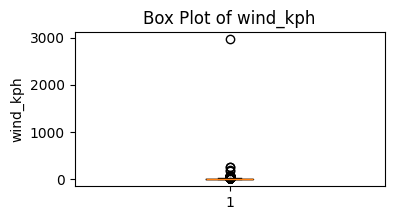

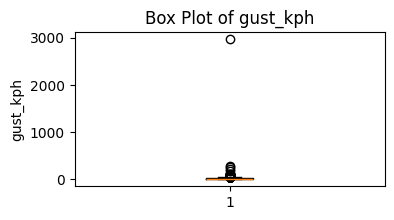

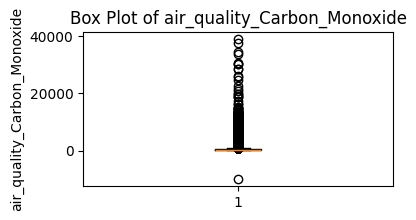

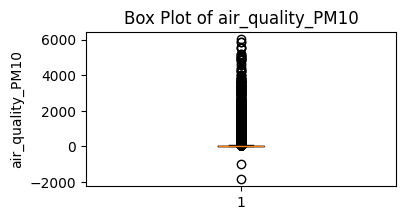

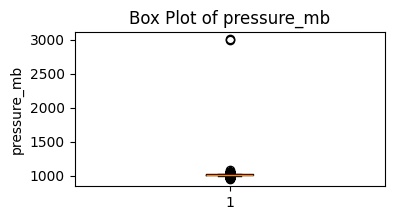

In [31]:
cols = ["wind_kph", "gust_kph", "air_quality_Carbon_Monoxide","air_quality_PM10","pressure_mb"]

for col in cols:
   plt.figure(figsize=(4, 2))
   plt.boxplot(df[col])
   plt.title(f"Box Plot of {col}")
   plt.ylabel(col)
   plt.show()

**Interpretation**
- During data validation and outlier analysis, I identified several **data errors in the numerical columns.**
- The **wind speed** had an unrealistic value of **2963.2 km/h,** and **gust speed** had an unrealistic value of **2970.4 km/h.**
- The **Carbon Monoxide** column contained a negative value of **-9999,** and the **PM10 column** contained a negative value of **-1848.15,** which are physically invalid.
- The **pressure column** also contained an extreme value of **3000 & 3006 mb**. I treated these clearly invalid or unrealistic observations as data errors and handled them during the data-cleaning process.

**Wind Kph Column**

- When i identified a clearly invalid data value i checked the record  before removing it.
- If the record was considered unreliable due to data error i removed the entire row.

In [32]:
## Wind kph Column
## Remove data error

df = df.loc[df["wind_kph"] !=2963.2 ]

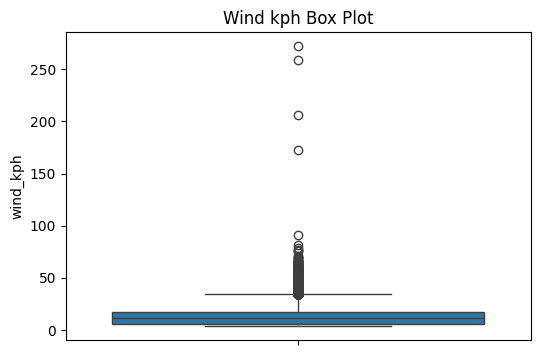

In [33]:
## After removing Data Error

plt.figure(figsize=(6,4))
sns.boxplot(y="wind_kph", data=df)
plt.title("Wind kph Box Plot")
plt.show()

**Gust Kph Column**

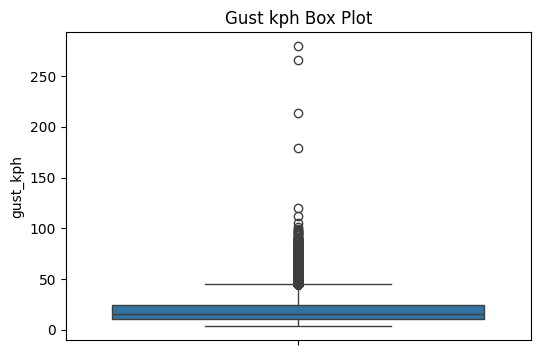

In [34]:
## Gust kph Column

plt.figure(figsize=(6,4))
sns.boxplot(y="gust_kph", data=df)
plt.title("Gust kph Box Plot")
plt.show()

**Air QUality Carbon Monoxide Column**

- I found a single invalid value of -9999 in the Carbon Monoxide column. Since it was a negative and unrealistic value, I removed that record.

In [35]:
## Air Quality Carbon Monoxide Column

df = df.loc[df["air_quality_Carbon_Monoxide"] != -9999]

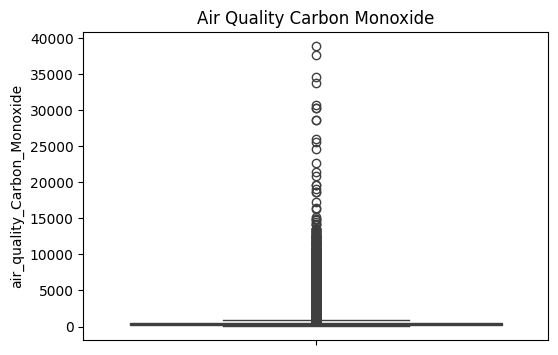

In [36]:
## After removing Data Error


plt.figure(figsize=(6,4))
sns.boxplot(y="air_quality_Carbon_Monoxide", data=df)
plt.title("Air Quality Carbon Monoxide")
plt.show()

**Pressure mb Column**

- Two extreme values 3000 and 3006 mb, were identified in the pressure column.
- These values were treated as outliers and replaced with the median pressure value to avoid the effect of extreme values

In [37]:
## Pressure mb Column

df["pressure_mb"] = df["pressure_mb"].replace([3000,3006],df["pressure_mb"].median())

In [38]:
## After removing Data Error

df["pressure_mb"].describe()

,pressure_mb
count,125693.000000
mean,1014.024568
std,7.015132
min,947.000000
25%,1010.000000
50%,1014.000000
75%,1018.000000
max,1080.000000


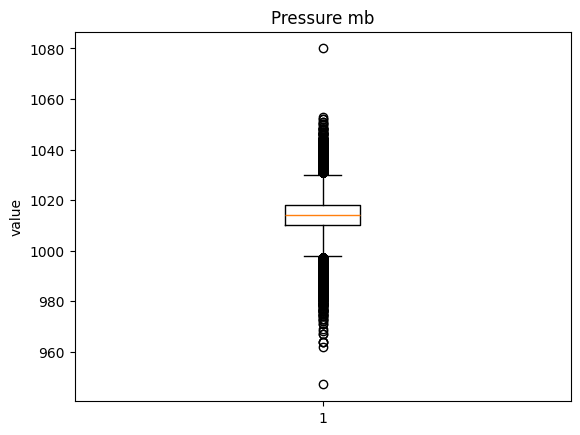

In [39]:
## After removing Data Error

plt.figure()
plt.boxplot(df["pressure_mb"])
plt.title("Pressure mb")
plt.ylabel("value")
plt.show()

**Air Quality PM10 Column**

- I found negative values in the PM10 column. Since PM10 concentration cannot be negative, I identified them as invalid values and removed those records from the dataset.

In [40]:
## Air Quality PM 10 Column

df = df.drop(df[df["air_quality_PM10"] < 0].index)

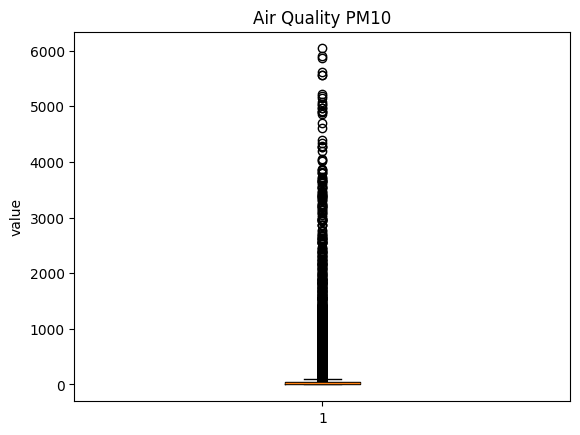

In [41]:
## After removing data error
plt.figure()
plt.boxplot(df["air_quality_PM10"])
plt.title("Air Quality PM10")
plt.ylabel("value")
plt.show()

## Data Tranfomation

**Data Type Conversion**

In [61]:
## Last Updated Column

df["last_updated"] = pd.to_datetime(df["last_updated"], dayfirst= True)

In [62]:
## After Tranformation Check the Datatypes

print("Data Type")
df.dtypes

Data Type


,0
country,object
location_name,object
latitude,float64
longitude,float64
timezone,object
last_updated,datetime64[ns]
temperature_celsius,float64
weather_condition,object
wind_kph,float64
wind_degree,int64


In [63]:
## Change the Condition_text column name into Weather_Condition

df = df.rename(columns = {"condition_text" : "weather_condition"})

In [64]:
## Column names

print(df.columns)

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated', 'temperature_celsius', 'weather_condition', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'pollution_category',
       'temperature_category', 'month_name'],
      dtype='object')


## Feature Engineering

In [46]:
## To Create Pollution Category Column using def function

def pollution_category(n):
  if(n == 1):
    return "Good"
  elif(n == 2):
    return "Moderate"
  elif (n == 3 or n == 4 ):
    return "Unhealthy"
  elif (n == 5):
    return "Very Unhealthy"
  else:
    return "Hazardous"

df["pollution_category"] = df["air_quality_us-epa-index"].apply(pollution_category)
df.head(5)

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,weather_condition,wind_kph,wind_degree,...,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,pollution_category
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,10.0,7.0,15.3,277.0,103.0,1.1,8.4,26.6,1,Good
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly Cloudy,11.2,320,...,10.0,5.0,18.4,193.6,97.3,0.9,1.1,2.0,1,Good
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280,...,10.0,5.0,22.3,540.7,12.2,65.1,10.4,18.4,1,Good
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 10:45:00,6.3,Light Drizzle,11.9,215,...,2.0,2.0,13.7,170.2,64.4,1.6,0.7,0.9,1,Good
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly Cloudy,13.0,150,...,10.0,8.0,20.2,2964.0,19.0,72.7,183.4,262.3,5,Very Unhealthy


In [47]:
## To Create a Temperature Category

def temperature_category(n):
    if n < 0:
        return "Freezing"
    elif n < 15:
        return "Cold"
    elif n < 30:
        return "Moderate"
    else:
        return "Hot"
df["temperature_category"] = df["temperature_celsius"].apply(temperature_category)
df.sample(3)

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,weather_condition,wind_kph,wind_degree,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,pollution_category,temperature_category
36287,Australia,Canberra,-35.2833,149.2167,Australia/Sydney,2024-11-20 19:45:00,17.3,Sunny,20.2,103,...,0.3,26.9,194.25,71.0,4.255,17.945,19.61,2,Moderate,Moderate
115393,Bolivia,Sucre,-19.0431,-65.2592,America/La_Paz,2025-12-31 03:00:00,12.7,Partly Cloudy,5.8,4,...,0.0,7.7,163.85,48.0,4.350,2.950,3.25,1,Good,Cold
78908,Uruguay,Montevideo,-34.8581,-56.1708,America/Montevideo,2025-06-26 06:00:00,2.0,Partly Cloudy,11.2,248,...,0.0,18.3,407.00,41.0,14.615,16.835,19.24,2,Moderate,Cold


**Time data extracted from Last Updated Column**
-  For Time base Analysis

In [83]:
## Extract Time
df["update_hour"] = df["last_updated"].dt.hour

In [84]:
## After extract the hour

df.head(3)

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,weather_condition,wind_kph,wind_degree,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,pollution_category,temperature_category,month_name,update_hour
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,277.0,103.0,1.1,8.4,26.6,1,Good,Moderate,May,13
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly Cloudy,11.2,320,...,193.6,97.3,0.9,1.1,2.0,1,Good,Moderate,May,10
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280,...,540.7,12.2,65.1,10.4,18.4,1,Good,Moderate,May,9


## Month Extraxtion

In [85]:
## Extract Month

df["month_name"] = df["last_updated"].dt.month_name()

In [86]:
df["month_name"] = pd.Categorical(
    df["month_name"],
    categories=[
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ],
    ordered=True
)

In [54]:
df["month_name"].value_counts()

,count
month_name,
December,12090
August,12089
October,12064
January,11844
September,11703
November,11668
June,11651
July,11622
February,9744


In [87]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,weather_condition,wind_kph,wind_degree,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,pollution_category,temperature_category,month_name,update_hour
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,277.0,103.0,1.1,8.4,26.6,1,Good,Moderate,May,13
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly Cloudy,11.2,320,...,193.6,97.3,0.9,1.1,2.0,1,Good,Moderate,May,10
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280,...,540.7,12.2,65.1,10.4,18.4,1,Good,Moderate,May,9
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 10:45:00,6.3,Light Drizzle,11.9,215,...,170.2,64.4,1.6,0.7,0.9,1,Good,Cold,May,10
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly Cloudy,13.0,150,...,2964.0,19.0,72.7,183.4,262.3,5,Very Unhealthy,Moderate,May,9


## Final EDA

**Dataset Overview**

In [55]:
## Display first 3 Rows

df.head(3)

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,weather_condition,wind_kph,wind_degree,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,pollution_category,temperature_category,month_name
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,15.3,277.0,103.0,1.1,8.4,26.6,1,Good,Moderate,May
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly Cloudy,11.2,320,...,18.4,193.6,97.3,0.9,1.1,2.0,1,Good,Moderate,May
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280,...,22.3,540.7,12.2,65.1,10.4,18.4,1,Good,Moderate,May


In [56]:
## Shape of Dataset

df.shape

(125691, 28)

In [57]:
## Information of the Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125691 entries, 0 to 125695
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       125691 non-null  object        
 1   location_name                 125691 non-null  object        
 2   latitude                      125691 non-null  float64       
 3   longitude                     125691 non-null  float64       
 4   timezone                      125691 non-null  object        
 5   last_updated                  125691 non-null  datetime64[ns]
 6   temperature_celsius           125691 non-null  float64       
 7   weather_condition             125691 non-null  object        
 8   wind_kph                      125691 non-null  float64       
 9   wind_degree                   125691 non-null  int64         
 10  wind_direction                125691 non-null  object        
 11  pressure_mb       

In [65]:
## Statistical Summary

df.describe()

,latitude,longitude,last_updated,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index
count,125691.000000,125691.000000,125691,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000,125691.000000
mean,19.194521,21.992002,2025-04-05 04:10:12.516409344,21.566100,12.959654,169.193419,1014.024425,0.136675,66.179440,40.036884,22.455924,9.516108,3.430491,18.289470,475.327953,58.849419,15.234244,24.558451,49.175345,1.709088
min,-41.300000,-175.200000,2024-05-16 01:45:00,-29.800000,3.600000,1.000000,947.000000,0.000000,2.000000,0.000000,-36.700000,0.000000,0.000000,3.600000,54.850000,0.000000,0.000000,0.168000,0.168000,1.000000
25%,3.750000,-6.836100,2024-10-25 19:45:00,16.300000,6.100000,80.000000,1010.000000,0.000000,50.000000,0.000000,16.300000,10.000000,0.100000,10.400000,210.823000,39.000000,1.665000,7.100000,10.000000,1.000000
50%,17.250000,23.240000,2025-04-05 11:00:00,24.100000,11.200000,162.000000,1014.000000,0.000000,71.000000,31.000000,25.300000,10.000000,2.100000,15.500000,302.850000,56.000000,5.500000,14.245000,20.250000,1.000000
75%,40.400000,50.580000,2025-09-13 12:15:00,28.100000,17.600000,256.000000,1018.000000,0.030000,85.000000,75.000000,30.100000,10.000000,6.000000,24.300000,471.750000,75.000000,17.760000,28.120000,42.180000,2.000000
max,64.150000,179.220000,2026-02-22 19:45:00,49.200000,272.200000,360.000000,1080.000000,42.240000,100.000000,100.000000,51.200000,32.000000,16.300000,279.400000,38879.398000,480.700000,427.700000,1614.100000,6037.290000,6.000000
std,24.425200,65.794538,NaN,9.615559,8.418062,103.475755,7.015078,0.570399,24.023781,34.087827,11.496032,2.674129,3.564182,11.245785,779.863721,31.095535,24.229080,37.702938,151.411573,0.949868


**Misssing values check**

In [60]:
## Check missing Values

df.isnull().sum()

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated,0
temperature_celsius,0
weather_condition,0
wind_kph,0
wind_degree,0


## Stage 3

## Statistical analysis & Visualizations ##

-  MEASURE OF CENTRAL TENDENCY



- Its identify **central & typical** value of dataset.
- **Common Measures** Mean, Median, Mode

I excluded wind_degree from central tendency analysis because it represents circular directional data in degrees, where mean and median are not meaningful for interpretation.

In [66]:
## MEASURE OF CENTRAL TENDENCY

cols = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_PM2.5', 'air_quality_PM10']


central_tendency = pd.DataFrame({
    "Mean": df[cols].mean(),
    "Median": df[cols].median(),
    "Mode": df[cols].mode().iloc[0]
})

print(f" Measure of Cental Tendency:\n {central_tendency}")



 Measure of Cental Tendency:
                                      Mean    Median     Mode
temperature_celsius             21.566100    24.100    26.30
wind_kph                        12.959654    11.200     3.60
pressure_mb                   1014.024425  1014.000  1013.00
precip_mm                        0.136675     0.000     0.00
humidity                        66.179440    71.000    94.00
cloud                           40.036884    31.000     0.00
feels_like_celsius              22.455924    25.300    24.60
visibility_km                    9.516108    10.000    10.00
uv_index                         3.430491     2.100     0.00
gust_kph                        18.289470    15.500    10.80
air_quality_Carbon_Monoxide    475.327953   302.850   217.00
air_quality_Ozone               58.849419    56.000    51.00
air_quality_Nitrogen_dioxide    15.234244     5.500     0.00
air_quality_PM2.5               24.558451    14.245     0.50
air_quality_PM10                49.175345    20.250    

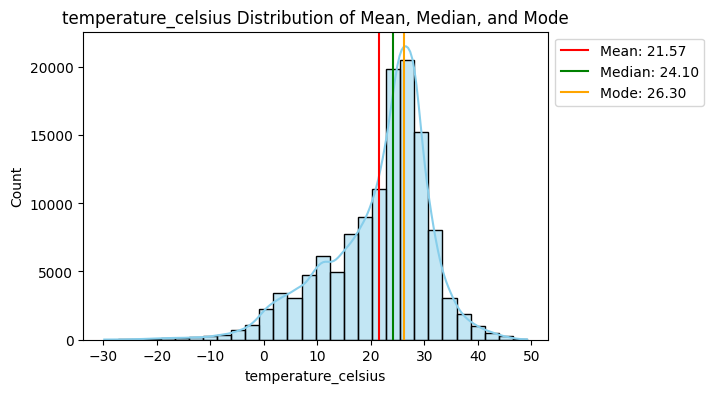

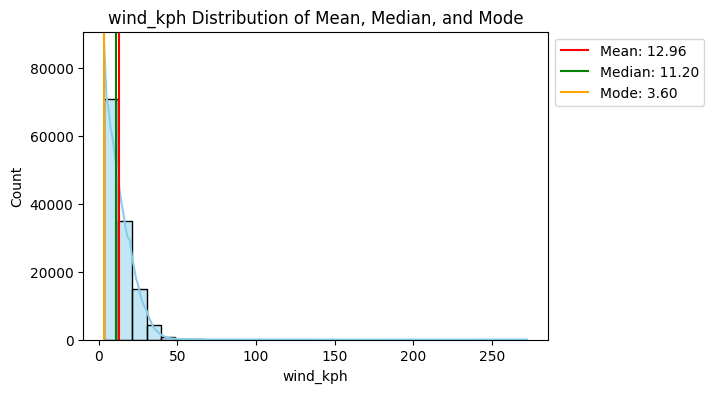

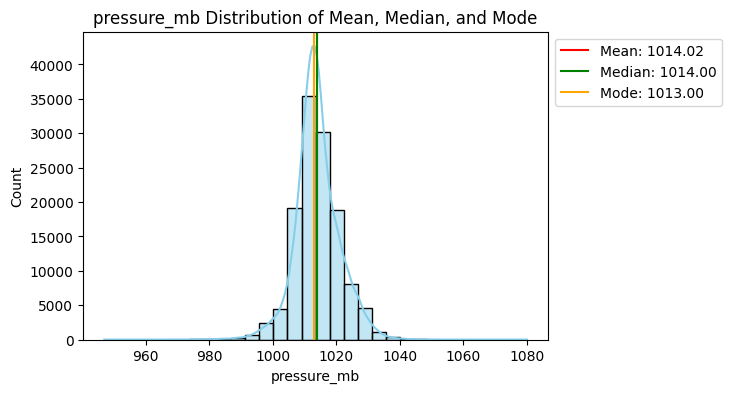

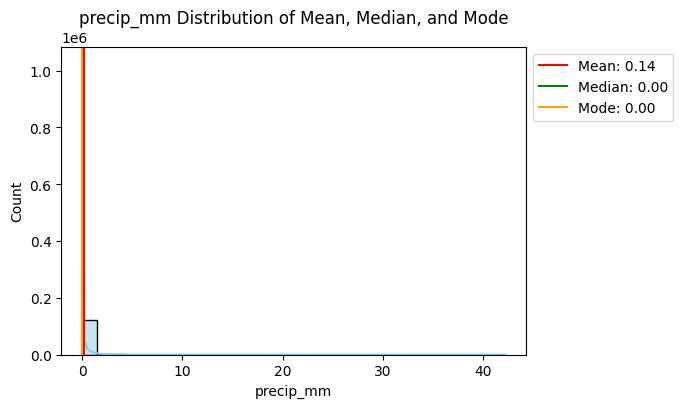

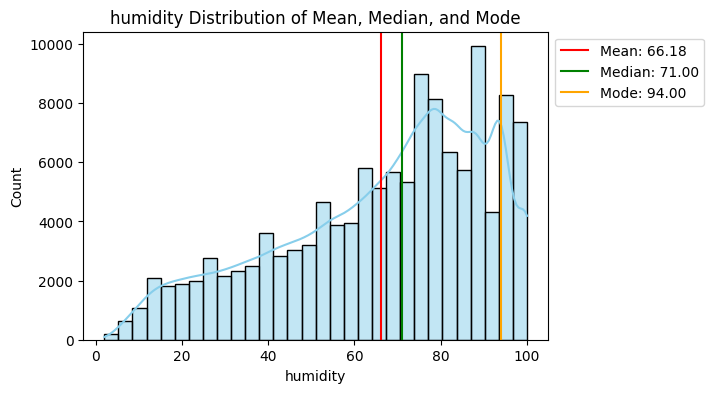

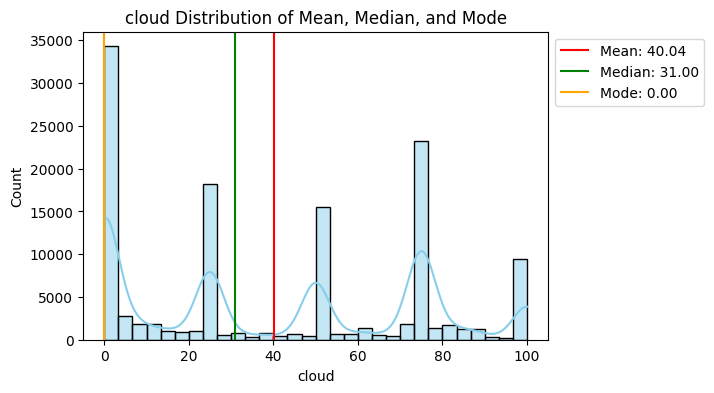

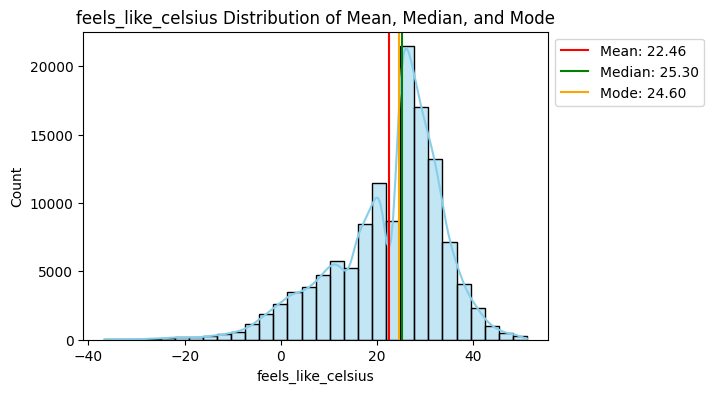

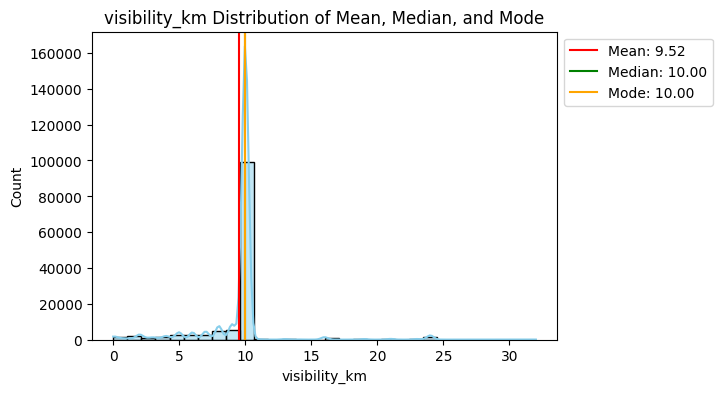

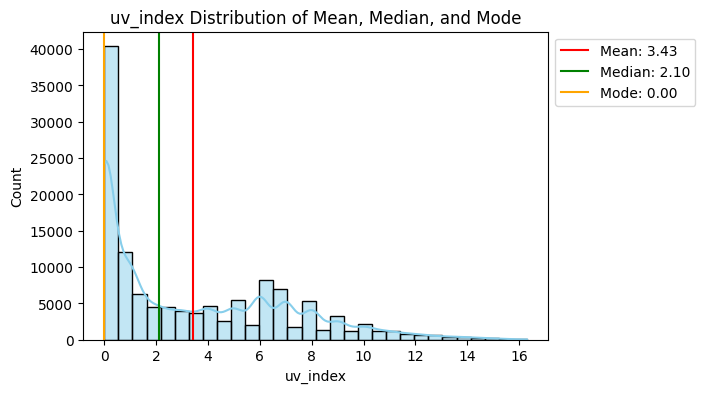

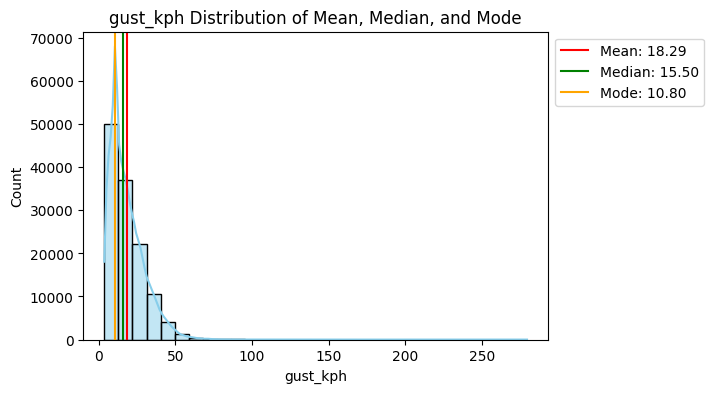

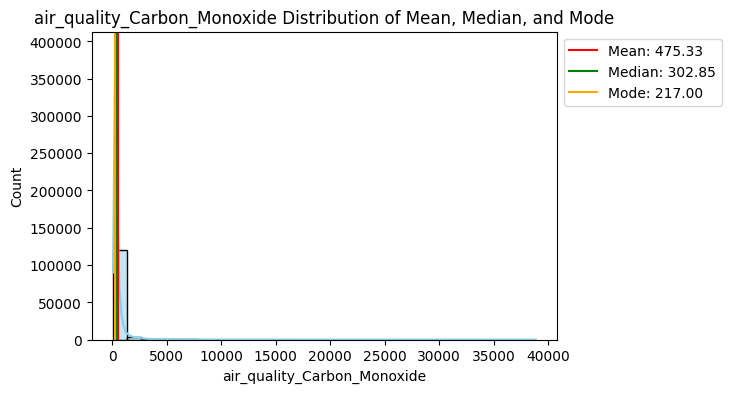

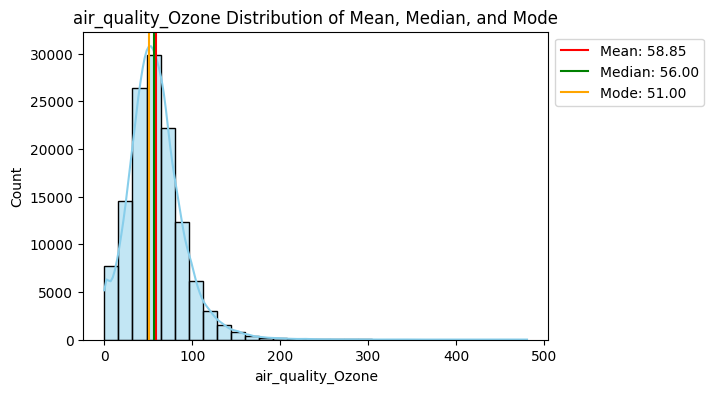

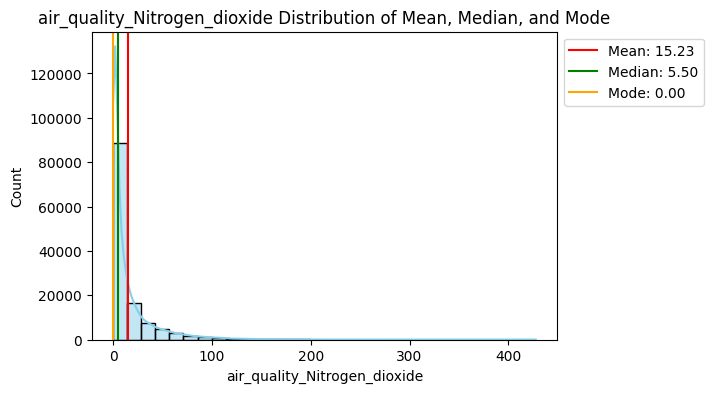

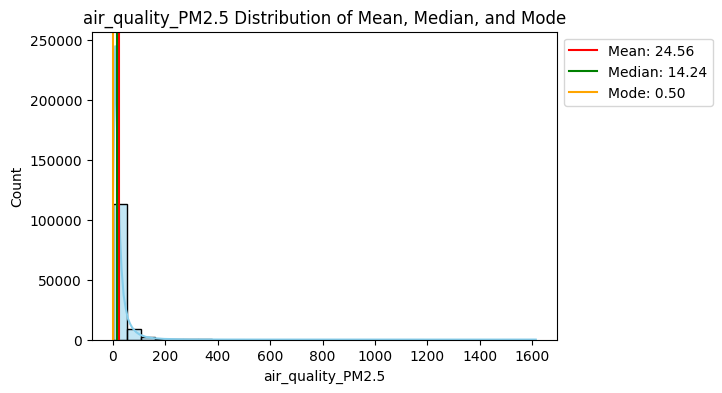

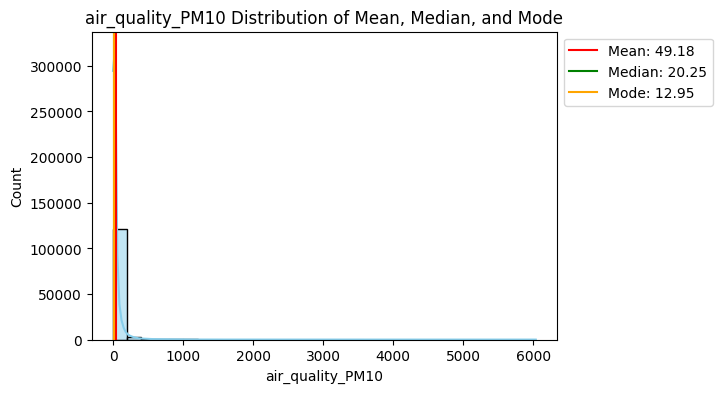

In [67]:
## Visualization Chart for Central Tendency

for col in cols:
  mean_val = central_tendency.loc[col,"Mean"]
  median_val = central_tendency.loc[col,"Median"]
  mode_val = central_tendency.loc[col,"Mode"]

  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True, bins=30, color='skyblue')

  plt.axvline(mean_val, color="red", label=f"Mean: {mean_val:.2f}")
  plt.axvline(median_val, color="green", label=f"Median: {median_val:.2f}")
  plt.axvline(mode_val, color="orange", label=f"Mode: {mode_val:.2f}")

  plt.title(f"{col} Distribution of Mean, Median, and Mode")
  plt.legend(loc="upper left", bbox_to_anchor=(1,1))
  plt.show()



## Insights for Measure of Central Tendency

-   **Temperature (temperature_celsius):** The mean (21.57°C) is slightly lower than the median (24.10°C), suggesting a slight left-skewness due to some lower temperature readings. The mode (26.30°C) indicates a frequent occurrence of temperatures around this value.

-   **Wind Speed (wind_kph):** The mean (12.96 km/h) is higher than the median (11.20 km/h), implying a right-skewed distribution, possibly due to a few instances of higher wind speeds. The mode (3.60 km/h) indicates very calm conditions are common.

-   **Atmospheric Pressure (pressure_mb):** The mean (1014.02 mb) and median (1014.00 mb) are very close, indicating a fairly symmetrical and balanced distribution of atmospheric pressure.

-   **Precipitation (precip_mm):** The mean (0.14 mm) is significantly higher than both the median (0.00 mm) and mode (0.00 mm). This heavily right-skewed distribution indicates that most observations recorded no precipitation, with occasional instances of rainfall.

-   **Humidity:** The mean (66.18%) is lower than the median (71.00%), and the mode (94.00%) is considerably higher. This suggests a left-skewed distribution, with a large number of observations experiencing high humidity levels.

-   **Cloud Cover:** The mean (40.04%) is higher than the median (31.00%), and the mode is 0%. This indicates a right-skewed distribution, meaning many observations have clear skies (0% cloud), but some have higher cloud coverage.

-   **Feels Like Temperature (feels_like_celsius):** The mean (22.46°C) is lower than the median (25.30°C), similar to `temperature_celsius`, indicating a slight left-skewness due to periods of lower perceived temperatures.

-   **Visibility (visibility_km):** The mean (9.52 km) is slightly lower than the median and mode (both 10.00 km), suggesting that good visibility (10 km) is the most common condition, with some instances of reduced visibility.

-   **UV Index:** The mean (3.43) is considerably higher than the median (2.10) and mode (0.00). This indicates a right-skewed distribution where many observations have very low UV levels, but there are instances of higher UV radiation.

-   **Gust Speed (gust_kph):** The mean (18.29 km/h) is higher than the median (15.50 km/h), and the mode is lower (10.80 km/h), pointing to a right-skewed distribution due to stronger gusts in some instances.

-   **Air Quality Parameters (Carbon Monoxide, Ozone, Nitrogen Dioxide, PM2.5, PM10):** For most air quality parameters, the mean is significantly higher than the median and mode (where applicable). This indicates a strong right-skewness, meaning that while lower pollution levels are common, there are infrequent but significant occurrences of high pollution concentrations, pulling the mean upwards.
    -   `air_quality_Carbon_Monoxide`: Mean (475.33) >> Median (302.85) >> Mode (217.00)
    -   `air_quality_Nitrogen_dioxide`: Mean (15.23) >> Median (5.50) >> Mode (0.00)
    -   `air_quality_PM2.5`: Mean (24.56) >> Median (14.25) >> Mode (0.50)
    -   `air_quality_PM10`: Mean (49.18) >> Median (20.25) >> Mode (12.95)

In summary, the central tendency measures highlight that many variables, especially precipitation and air quality indicators, exhibit right-skewed distributions, implying that lower values are more common, but extreme high values exist and significantly influence the mean.

## Measure of Disperison : Range
- Represents the smallest and largest value in a data set.

In [68]:
## Range

cols = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_PM2.5', 'air_quality_PM10']
summary = pd.DataFrame({
    "Min" : df[cols].min(),
    "Max" : df[cols].max(),
    "Range" : df[cols].max() - df[cols].min()
})
print(f"Measure of Disperison: Range:\n {summary}")


Measure of Disperison: Range:
                                   Min        Max      Range
temperature_celsius           -29.800     49.200     79.000
wind_kph                        3.600    272.200    268.600
pressure_mb                   947.000   1080.000    133.000
precip_mm                       0.000     42.240     42.240
humidity                        2.000    100.000     98.000
cloud                           0.000    100.000    100.000
feels_like_celsius            -36.700     51.200     87.900
visibility_km                   0.000     32.000     32.000
uv_index                        0.000     16.300     16.300
gust_kph                        3.600    279.400    275.800
air_quality_Carbon_Monoxide    54.850  38879.398  38824.548
air_quality_Ozone               0.000    480.700    480.700
air_quality_Nitrogen_dioxide    0.000    427.700    427.700
air_quality_PM2.5               0.168   1614.100   1613.932
air_quality_PM10                0.168   6037.290   6037.122


## Interpretation
- The range analysis shows that the numerical variables have different levels of variability. **Temperature** ranges from **-29.8°C to 49.2°C**, giving a range of **79°C**, which indicates considerable variation in temperature across locations.
- **Humidity and cloud cover** show a wide range of **98% and 100%** respectively.
- **Wind speed and gust speed** also have large ranges of 268.6 km/h and 275.8 km/h, indicating high variability and the presence of extreme observations.
- The air-quality variables show much larger ranges, particularly **Carbon Monoxide (38,824.548), PM2.5 (1,613.932), and PM10 (6,037.122),** indicating substantial variation in pollution levels across the dataset.
- Overall, the range analysis shows that air-quality variables have greater dispersion compared with most weather variables.

## Variance
- Variance is a measure of how far the data values are spread out from the mean (average).

In [69]:
## Variance

variance = df[cols].var()
print("Measure of Disperison: Variance\n ")
print(variance)

Measure of Disperison: Variance
 
temperature_celsius                 92.458965
wind_kph                            70.863770
pressure_mb                         49.211322
precip_mm                            0.325355
humidity                           577.142071
cloud                             1161.979927
feels_like_celsius                 132.158749
visibility_km                        7.150968
uv_index                            12.703395
gust_kph                           126.467673
air_quality_Carbon_Monoxide     608187.423778
air_quality_Ozone                  966.932293
air_quality_Nitrogen_dioxide       587.048315
air_quality_PM2.5                 1421.511537
air_quality_PM10                 22925.464586
dtype: float64


## Interpretation
- **Temperature:** A variance of **92.46** indicates noticeable temperature variation across locations.

- **Precipitation:** A very low variance of 0.33 suggests that rainfall values are predominantly low or zero, meaning precipitation is fairly consistent (low).

- **Cloud Cover:** With a variance of **1,161.98,** cloud cover shows considerable variation from one location to another.

- **Wind Gust:** A variance of 126.47 points to noticeable differences in wind gust intensity.

- **Air Quality Columns:**  **(PM2.5, Ozone, NO₂): Variances of 1,421.51, 966.93, and 587.05** respectively, indicate considerable variation in pollution levels for these metrics.

- **Air Quality PM10:** A very high variance of **22,925.46** signifies a very wide spread of PM10 values, implying high variability.

- Carbon Monoxide: The highest variance of 608,187.42 suggests extremely high variability in CO concentrations.

- Overall, air quality variables exhibit **greater dispersion compared to most weather variables.**

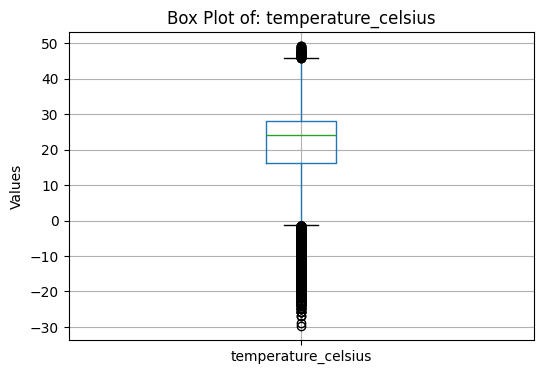

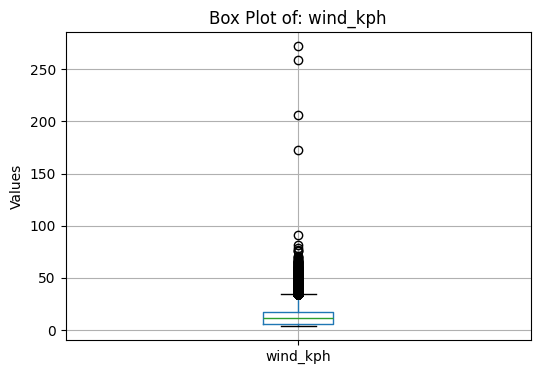

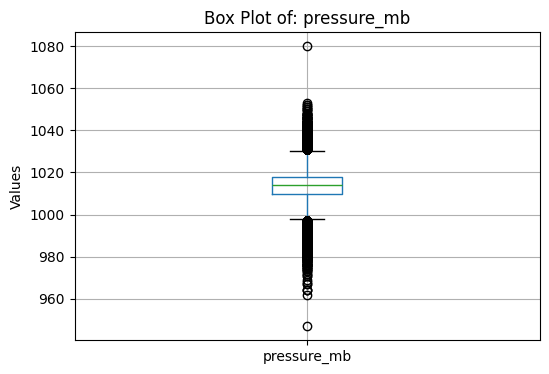

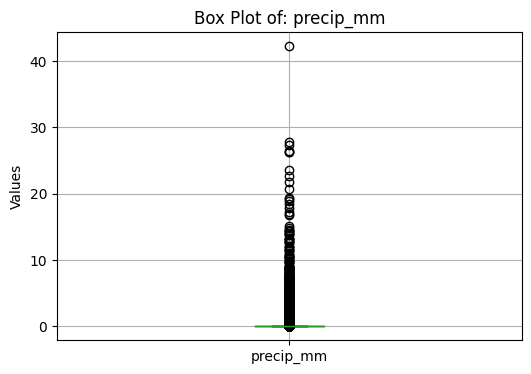

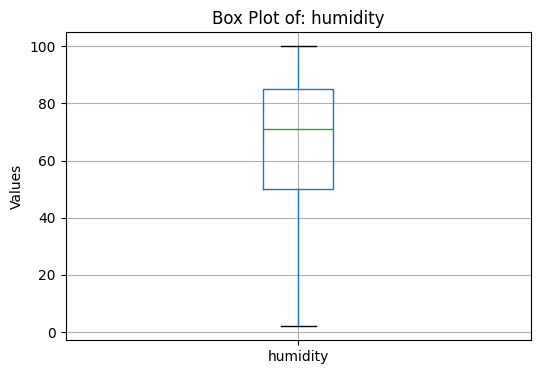

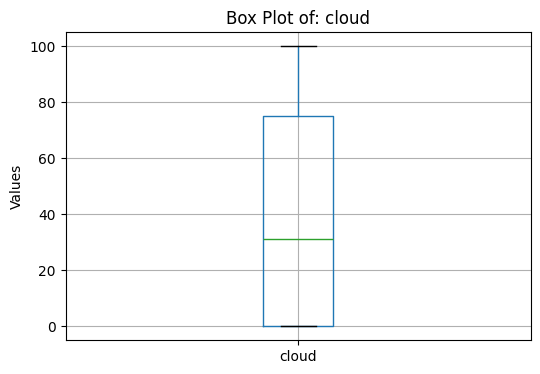

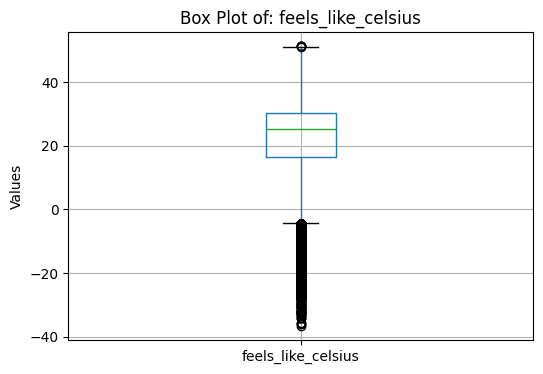

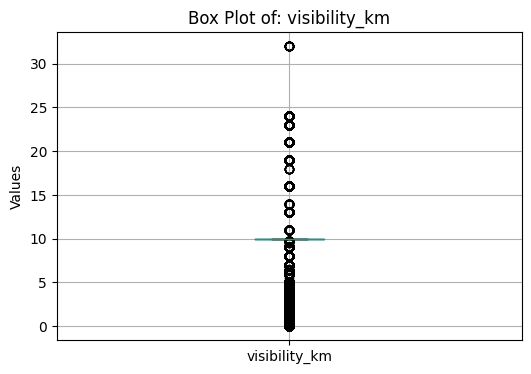

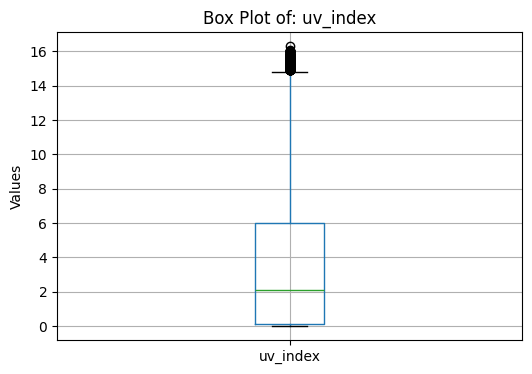

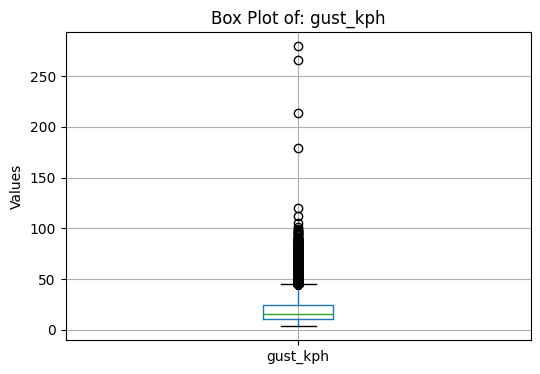

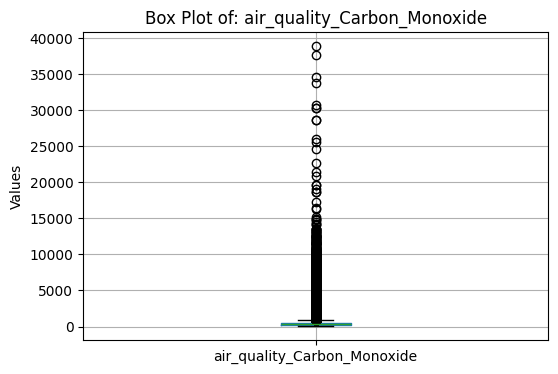

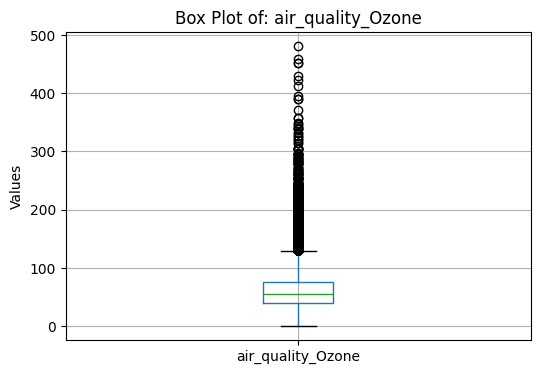

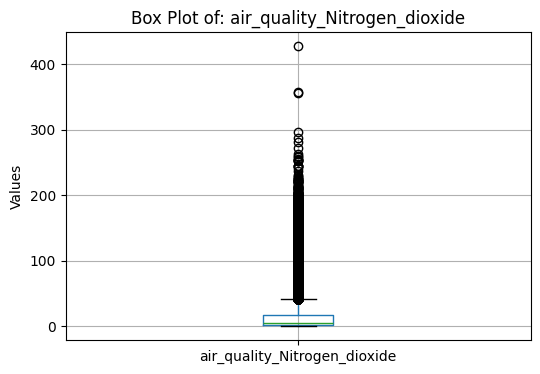

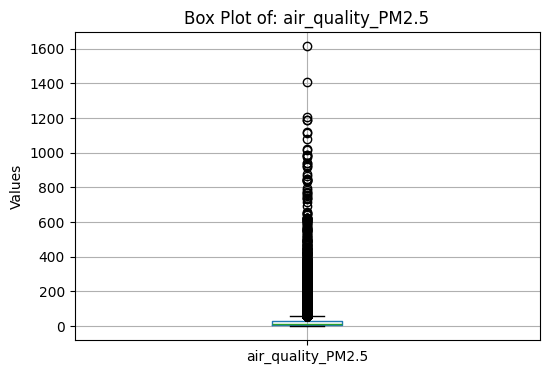

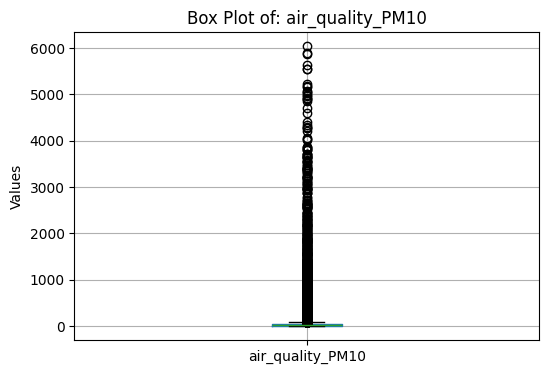

In [70]:
## Box Plot for Variance

for col in cols:
  plt.figure(figsize=(6,4))
  df.boxplot(column = col)
  plt.title(f"Box Plot of: {col}")
  plt.ylabel("Values")
  plt.show()

## Standard Deviation
- Standard Deviation (SD) is a measure that tells us how much the data values are spread out from the mean.

In [71]:
## Standard Deviation

std_dev = df[cols].std()
print("Measure of Disperison: Standard Deviation\n ")
print(std_dev)

Measure of Disperison: Standard Deviation
 
temperature_celsius               9.615559
wind_kph                          8.418062
pressure_mb                       7.015078
precip_mm                         0.570399
humidity                         24.023781
cloud                            34.087827
feels_like_celsius               11.496032
visibility_km                     2.674129
uv_index                          3.564182
gust_kph                         11.245785
air_quality_Carbon_Monoxide     779.863721
air_quality_Ozone                31.095535
air_quality_Nitrogen_dioxide     24.229080
air_quality_PM2.5                37.702938
air_quality_PM10                151.411573
dtype: float64


## Interpretation
Cloud cover (34.09) shows relatively high variability, indicating considerable differences in cloud conditions across observations.

Humidity (24.02) also shows noticeable variation, suggesting that moisture levels vary considerably across locations and observations.

Among the air-quality variables, PM10 (151.41) and Carbon Monoxide (779.86) show substantial dispersion around their respective means, indicating high variability and the presence of extreme values.

PM2.5 (37.70) and Ozone (31.10) also show considerable variation, while Nitrogen Dioxide (24.23) shows moderate variability.

Precipitation (0.57) and visibility (2.67) show relatively lower dispersion, indicating that their values are comparatively more consistent within their respective units.

Overall, the standard deviation results indicate that air-quality and cloud-related variables exhibit greater variation, while precipitation and visibility show relatively lower dispersion.

In [72]:
## Calculate mean for each column

mean = df[cols].mean()

## Deviation from mean

deviation = df[cols] - mean
deviation

,temperature_celsius,wind_kph,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_PM2.5,air_quality_PM10
0,5.0339,0.340346,-2.024425,-0.136675,-42.17944,-10.036884,2.844076,0.483892,3.569509,-2.98947,-198.327953,44.150581,-14.134244,-16.158451,-22.575345
1,-2.5661,-1.759654,-2.024425,-0.036675,27.82056,34.963116,-3.455924,0.483892,1.569509,0.11053,-281.727953,38.450581,-14.334244,-23.458451,-47.175345
2,1.4339,2.140346,-3.024425,-0.136675,-37.17944,-40.036884,2.144076,0.483892,1.569509,4.01053,65.372047,-46.649419,49.865756,-14.158451,-30.775345
3,-15.2661,-1.059654,-7.024425,0.163325,-5.17944,59.963116,-18.655924,-7.516108,-1.430491,-4.58947,-305.127953,5.550581,-13.634244,-23.858451,-48.275345
4,4.4339,0.040346,-3.024425,-0.136675,22.82056,9.963116,6.244076,0.483892,4.569509,1.91053,2488.672047,-39.849419,57.465756,158.841549,213.124655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125691,3.4339,-6.459654,-1.024425,-0.136675,16.82056,-40.036884,5.444076,0.483892,-3.430491,-4.68947,-200.477953,-7.849419,-10.384244,-21.008451,-44.825345
125692,0.8339,-2.559654,-5.024425,-0.006675,33.82056,34.963116,2.244076,-4.516108,-2.230491,-4.28947,41.522047,-19.849419,10.615756,2.791549,-18.525345
125693,-8.3661,-7.559654,3.975575,-0.136675,-49.17944,-40.036884,-9.255924,0.483892,1.769509,-12.08947,-335.477953,12.150581,-12.784244,-13.908451,-26.325345
125694,-2.9661,3.640346,-0.024425,-0.116675,26.82056,53.963116,-3.855924,0.483892,-1.630491,5.81053,-320.477953,-20.849419,-13.384244,-22.708451,-47.325345


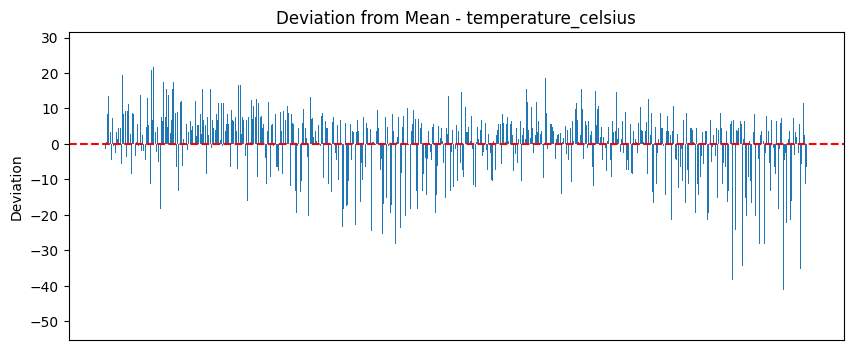

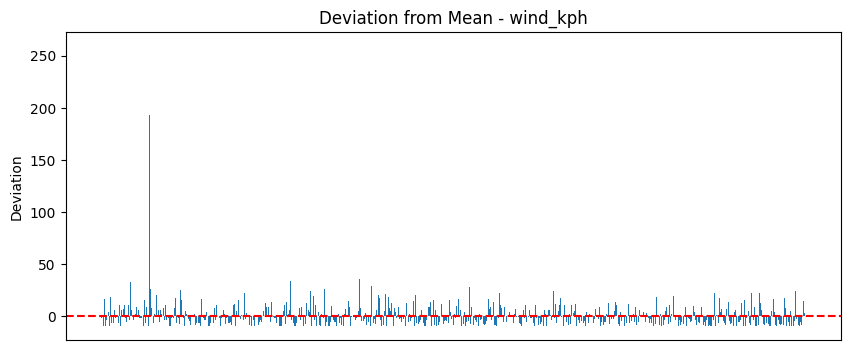

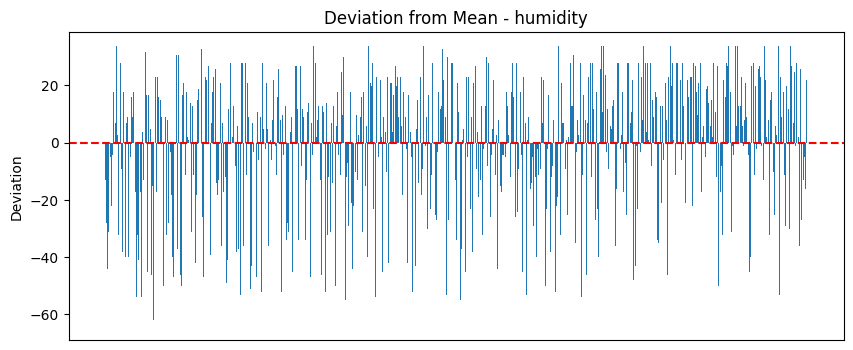

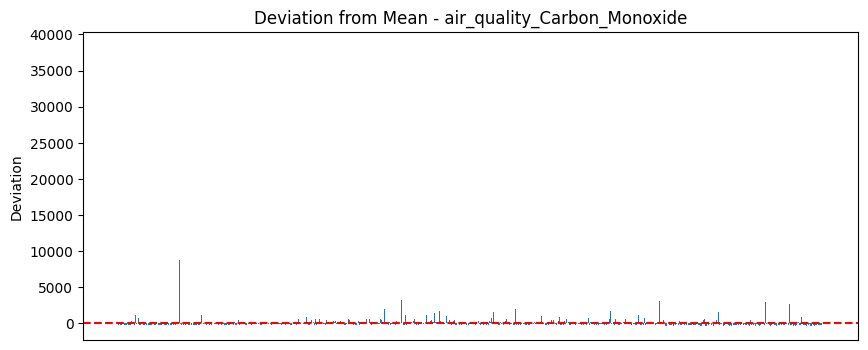

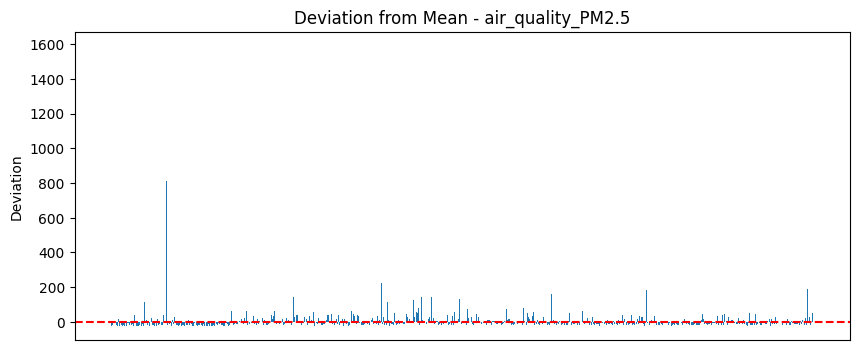

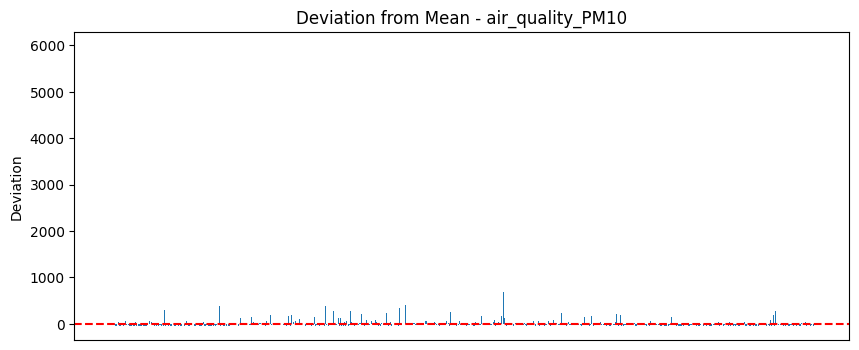

In [ ]:
## Bar Plot for Standard Deviation

cols = ["temperature_celsius","wind_kph","humidity",
        "air_quality_Carbon_Monoxide","air_quality_PM2.5","air_quality_PM10"]
deviation = df[cols] - df[cols].mean()
for col in cols:
    plt.figure(figsize=(10,4))
    plt.bar(range(len(deviation)), deviation[col])
    plt.axhline(0, color='red', linestyle='--')  # mean line
    plt.title(f'Deviation from Mean - {col}')
    plt.ylabel('Deviation')
    plt.xticks([])  # remove x-axis labels
    plt.show()

##Visualizations

##**Univariate Analysis**

## Temperature Distribution

- **Objective:** To analyze the distribution and variability of temperature across the dataset.

- **Attribute:** Temperature_celsius Column

- **Chart Type:** Histogram with Kernal Density Estimation (KDE)

- **Plot Summary:** Analyzes the frequency and density spread of ambient temperatures across dataset.


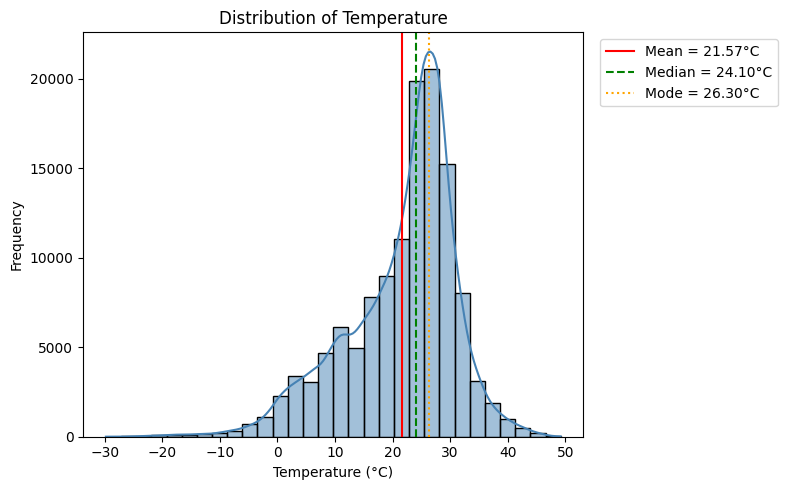

In [73]:
## Temperature Distribution

plt.figure(figsize=(8, 5))

sns.histplot(df["temperature_celsius"],kde=True, bins=30, color="steelblue")

# Mean, Median, Mode
mean_val = df["temperature_celsius"].mean()
median_val = df["temperature_celsius"].median()
mode_val = df["temperature_celsius"].mode()[0]

plt.axvline(mean_val,color="red",linestyle="solid",label=f"Mean = {mean_val:.2f}°C")

plt.axvline(median_val,color="green",linestyle="dashed",label=f"Median = {median_val:.2f}°C")

plt.axvline(mode_val, color="orange",linestyle="dotted", label=f"Mode = {mode_val:.2f}°C")

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.legend(bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()
plt.show()

Interpretation: Temperature Distribution

- The histogram shows a bell-shaped distribution, indicating that most temperature readings fall around a central value. The peak frequency appears to be between approximately 25°C and 30°C, suggesting that a significant portion of the observations were recorded within this moderate-to-warm temperature range.

- Temperatures range from around -30°C to 50°C, showing that the dataset covers different climatic conditions across the globe. Extreme temperatures have fewer observations.

- There are fewer observations at the extreme ends (very cold or very hot), which is typical for a natural phenomenon like temperature.   

##Top 10 Weather Conditions


- **Objective:** To identify and visualize the top most frequently occurring weather conditions in the dataset

- **Attribute:** Weather_Condition Column

- **Chart Type:** Horizontal Bar Chart

- **Plot Summary:** To determine the most common weather conditions and compare their frequency using the top 10 weather conditions.


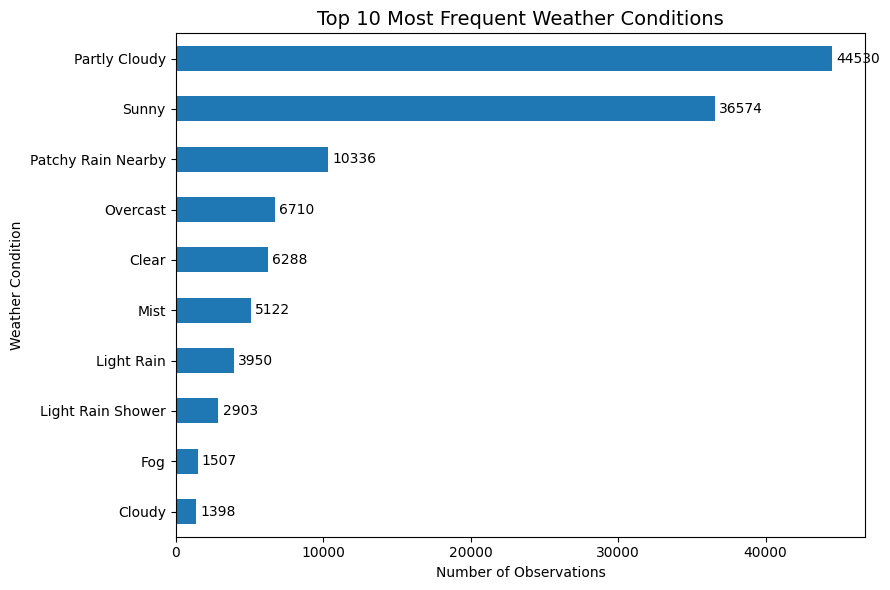

In [74]:
## Shows Top 10 Weather Conditions

plt.figure(figsize=(9, 6))

top_weather = df["weather_condition"].value_counts().head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Most Frequent Weather Conditions", fontsize=14)
plt.xlabel("Number of Observations")
plt.ylabel("Weather Condition")

for container in top_weather.containers:top_weather.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

Interpretation: Top Weather Conditions

- The bar chart clearly indicates that 'Sunny' is the most frequent weather condition, followed closely by 'Partly Cloudy'. This suggests that a large proportion of the data points collected reflect clear or mostly clear sky conditions.
- Other common conditions include 'Light Rain', 'Clear', and 'Mist', appearing less frequently than 'Sunny' or 'Partly Cloudy' but still significant.
-	The frequency drops off sharply after the top few conditions, indicating that more extreme or specific weather events (like 'Moderate Or Heavy Rain With Thunder' or 'Freezing Fog') are much rarer in this dataset.


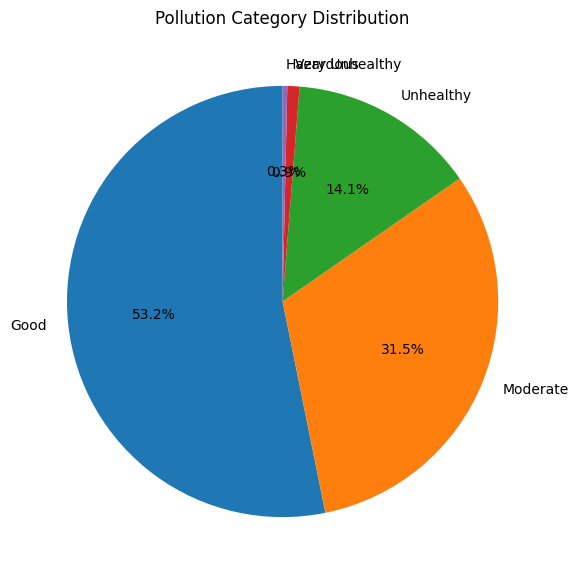

In [ ]:
## Pollution Category Count

counts = df["pollution_category"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%",startangle=90)
plt.title("Pollution Category Distribution")
plt.show()

Interpretation: Pollution Category Count

- The bar chart clearly indicates that the vast majority of observations fall into the **'Good' pollution category**. This suggests that for most of the recorded data points, air quality was considered healthy according to the US EPA index.
- The **'Moderate'** category is the second most frequent, but its count is significantly lower than 'Good'. This shows that while most air quality is good, there's a notable portion where it's at an acceptable but not ideal level.
- Categories like **'Unhealthy' and 'Very Unhealthy'** have much smaller counts, indicating that severe pollution events or locations are less common in this dataset.
- The **'Hazardous'** category is present but has the lowest count, implying that extremely dangerous air quality conditions are rare in the collected data.
- Overall, the distribution suggests that the dataset predominantly captures periods or locations with relatively good air quality, with fewer instances of moderate or unhealthy conditions, and very few instances of hazardous air quality.

## Distribution of Precipitation (Rainfall)
- **precip_mm** column - The amount of rainfall recorded at a specific location and time, measured in millimeters.

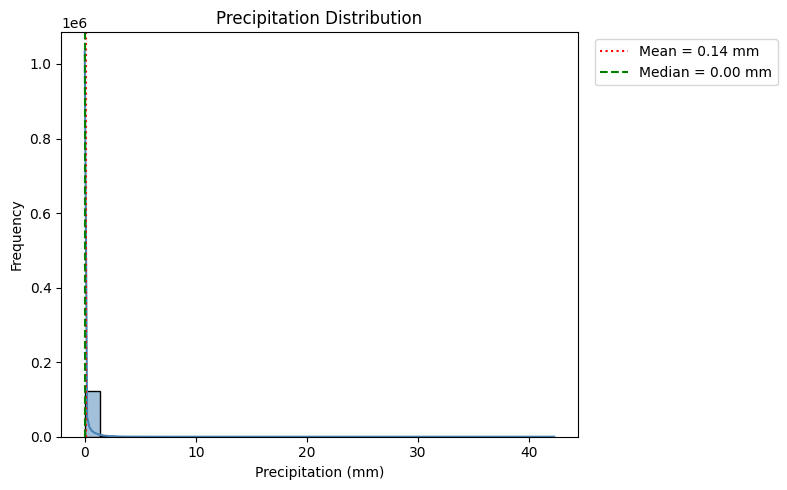

In [ ]:
## SHows Rainfall Distribution

plt.figure(figsize=(8, 5))

sns.histplot(df["precip_mm"],kde=True,bins=30, color="steelblue")

# Mean and Median
mean_val = df["precip_mm"].mean()
median_val = df["precip_mm"].median()

plt.axvline(mean_val,color="red",linestyle="dotted",label=f"Mean = {mean_val:.2f} mm")

plt.axvline(median_val,color="green",linestyle="dashed",label=f"Median = {median_val:.2f} mm")

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.legend(bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()
plt.show()

## Interpretation: Rainfall Distribution

- The histogram for rainfall (precip_mm) shows a **highly skewed distribution**, with a very large peak at or near zero.
- This indicates that **most observations in the dataset recorded no rainfall or very minimal rainfall**.
- The long tail extending to the right shows that while heavy rainfall events do occur, they are significantly less frequent compared to dry or nearly dry conditions.
- This pattern is typical for meteorological data, where periods of no precipitation are common, interspersed with occasional rainfall events of varying intensity.
- The concentration at zero also aligns with the central tendency analysis, which showed a mode of 0.00 for precip_mm.


## **Bivariate Analysis**

## Analyze Weather Conditions across Countries

- **Objective:** Analyze global weather conditions across countries

- **Attributes:** Country & Temperature_Celsius Column

- **Chart Type:** Horizontal Bar Chart

- **Plot Summary:** Compare the average temperature across the top 10 countries.


In [75]:
## Groupby method

country_temp = (df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(10))
country_temp

,temperature_celsius
country,
United Arab Emirates,32.691022
Qatar,32.685891
Djibouti,31.697360
Kuwait,31.614706
Oman,31.544737
Saudi Arabia,31.371229
Cambodia,31.281240
Bangladesh,30.729193
Thailand,30.711783


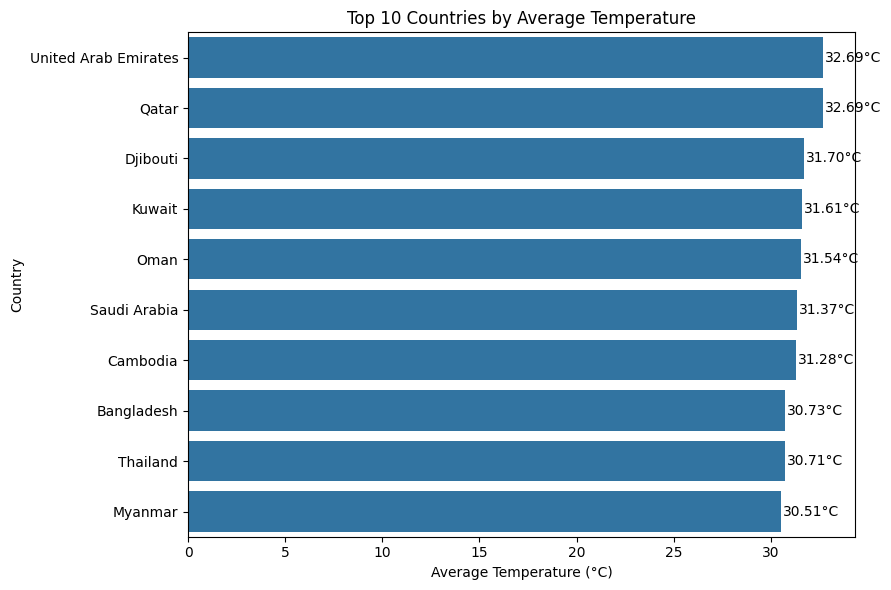

In [76]:
## shows weather conditions across countries

plt.figure(figsize=(9, 6))

ax = sns.barplot(x=country_temp.values,y=country_temp.index)

plt.title("Top 10 Countries by Average Temperature")

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")

# Add values on bars
for i, value in enumerate(country_temp.values):
    plt.text(value + 0.1,i,f"{value:.2f}°C",va="center")

plt.tight_layout()
plt.show()

**Interpretation** - Top 10 Countries by Average Temperature
- The chart shows that the top 10 countries have consistently high average temperatures, ranging approximately from 31°C to 33°C.
- The UAE and Qatar record the highest averages, while Myanmar has the lowest among these top 10 countries. Overall, the temperature variation between these countries is relatively small.
- This indicates a consistent warm-temperature pattern across the top 10 countries.

## Realtionship between Humidity & Air_Quality_PM2.5

- **Objective**:  To identify relationships between weather parameters and air quality indicators.

- **Attribute**: Humidity & Air_Quality_PM2.5 Columns

- **Chart Type:** Scatter Plot

- **Plot Summary:** To determine whether changes in humidity are associated with changes in PM2.5 concentration.


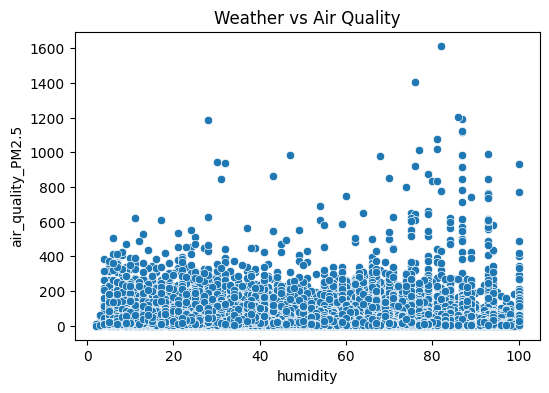

In [77]:
## Relationship betwen Weather pollution and Air Quality

plt.figure(figsize=(6,4))
sns.scatterplot(x="humidity",y="air_quality_PM2.5",data=df)
plt.title("Weather vs Air Quality")
plt.show()

**Interpretation**- Weather pollution and Air Quality
- The analysis shows a slight positive relationship between humidity and PM2.5.
- Most observations have relatively low PM2.5 levels, while higher PM2.5 concentrations occur more frequently at higher humidity.
- However, the wide scatter indicates that other environmental factors also influence PM2.5 levels.

## The relationship between actual temperature and feels-like temperature.

- **Objective:** To analyze the relationship between actual temperature and feels-like temperature

- **Attributes:** Temperature_Celsius & Feels_like_celsius

- **Chart Type:** Scatter Plot

- **Plot Summary:** To analyze the relationship between actual temperature and feels-like temperature and understand how closely they vary across different weather conditions.


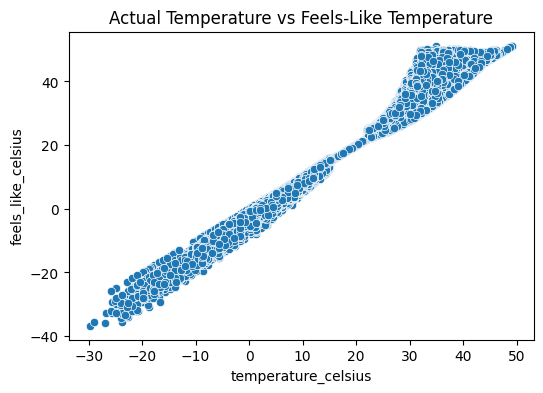

In [78]:
## Actual Temperature  and Feels like Temperature relationships
plt.figure(figsize=(6,4))
sns.scatterplot(x="temperature_celsius",y="feels_like_celsius",data=df)
plt.title("Actual Temperature vs Feels-Like Temperature")
plt.show()

**Interpretation** - wind_kph and air quality PM2.5
- The analysis shows that high PM2.5 concentrations are mostly observed at low wind speeds.
- As wind speed increases, PM2.5 values generally remain low, indicating a possible negative relationship between wind speed and PM2.5.

## Identify Higher pollution Countries

- **Objective:** To identify locations with higher pollution levels using air quality indicators and pollution category.

- **Attributes:** Country & Pollution_Category Columns

- **Chart Type:** Stacked Bar Chart

- **Plot Summary:** The stacked bar chart identifies the top 10 countries with the highest high-pollution observations and shows the contribution of each pollution severity category.


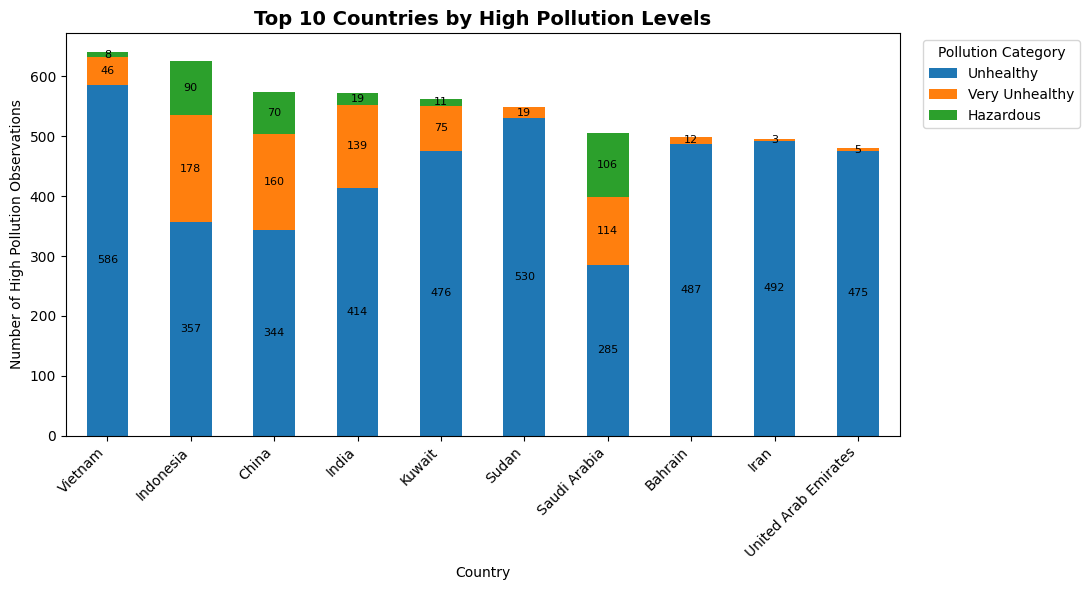

In [79]:
pollution_table = pd.crosstab(df["country"],df["pollution_category"])

high_pollution = ["Unhealthy","Very Unhealthy","Hazardous"]

available_categories = [col for col in high_pollution if col in pollution_table.columns]

# Calculate high pollution observations
high_pollution_count = (pollution_table[available_categories].sum(axis=1).sort_values(ascending=False).head(10))

top_countries = high_pollution_count.index

# Data for plotting
plot_data = pollution_table.loc[top_countries, available_categories]

# Plot
ax = plot_data.plot(kind="bar",stacked=True,figsize=(11, 6))

plt.title("Top 10 Countries by High Pollution Levels",fontsize=14,fontweight="bold")

plt.xlabel("Country")
plt.ylabel("Number of High Pollution Observations")

plt.xticks(rotation=45, ha="right")

# Add labels to each stacked section
for container in ax.containers:
    labels = [f"{int(v.get_height())}" if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container,labels=labels,label_type="center",fontsize=8)

plt.legend(title="Pollution Category",bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()
plt.show()

**Interpretation** - High pollution Country
- The analysis shows that pollution levels vary across countries. Good and Moderate categories are common in many locations, while countries such as Sudan, Indonesia, Iran, and Vietnam show relatively higher proportions of Unhealthy observations.
- This indicates that air quality differs significantly across locations.”

## Month-wise Pollution Category

- **Objective:** To analyze the monthly distribution and variation of pollution categories.
- **Attributes:** Country and Month_name Column
- **Chart Type:** Horizontal Bar Chart
- **Plot Summary:** The chart highlights monthly variations in pollution categories and identifies months with higher proportions of unhealthy air-quality levels.

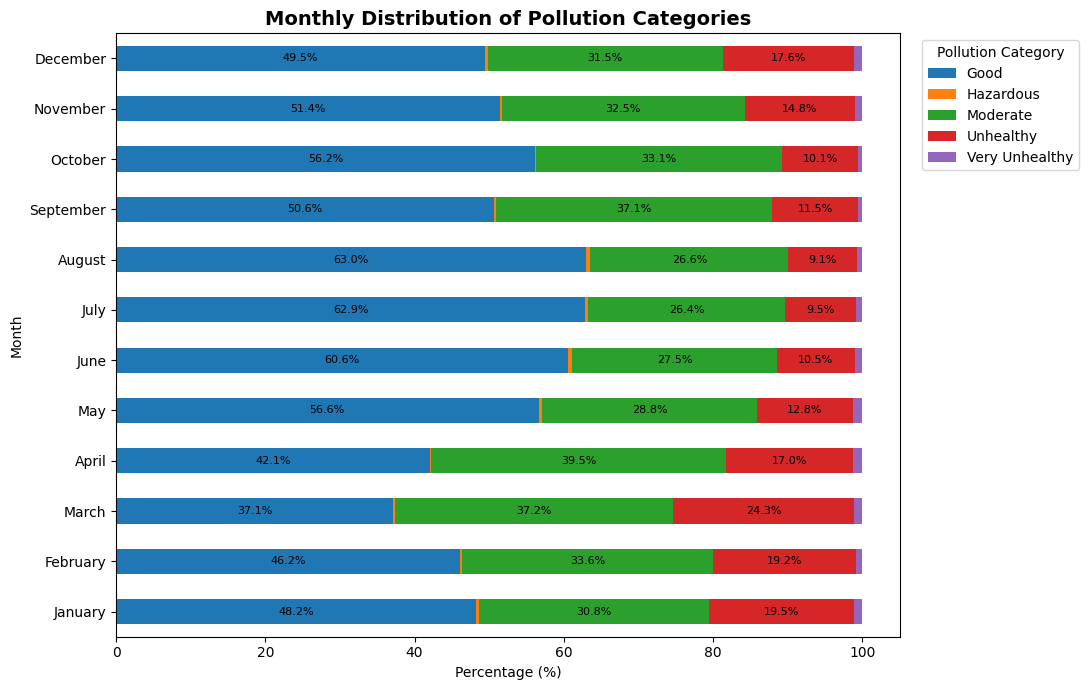

In [81]:
month_pollution = pd.crosstab(
    df["month_name"],
    df["pollution_category"],
    normalize="index"
) * 100

ax = month_pollution.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7)
)

plt.title(
    "Monthly Distribution of Pollution Categories",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Percentage (%)")
plt.ylabel("Month")

# Add percentage labels
for container in ax.containers:
    labels = []

    for bar in container:
        width = bar.get_width()

        if width >= 3:
            labels.append(f"{width:.1f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.legend(
    title="Pollution Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Interpretation
- Good pollution category is highest in **August (63.0%) and July (62.9%),** indicating better air-quality conditions during these months.

- **March** shows the **lowest Good category (37.1%) and the highest Unhealthy category (24.3%)**, indicating relatively poorer air quality.

- **April has the highest Moderate category (39.5%)**, followed by **March (37.2%) and September (37.1%).**

- **January and February** also show relatively **higher Unhealthy proportions** at **19.5% and 19.2%,** respectively.

- **Very Unhealthy and Hazardous** categories represent only a **small proportion** of observations across most months.

- Overall, the chart suggests **better pollution conditions during June–August and comparatively poorer conditions during March–April and January–February.**

## Multi-Variate Analysis

## Correlation Analysis

- **Objective:** To identify relationships between weather parameters and air quality.

- **Attributes:** temperature_celsius, wind_kph,  pressure_mb, precip_mm, humidity, visibility_km,                     air_quality_PM2.5,  air_quality_PM10

- **Chart Type:** Correlation Heatmap

- **Plot Summary:** To analyze the correlation between weather parameters and air quality indicators and identify the strength and direction of their relationships


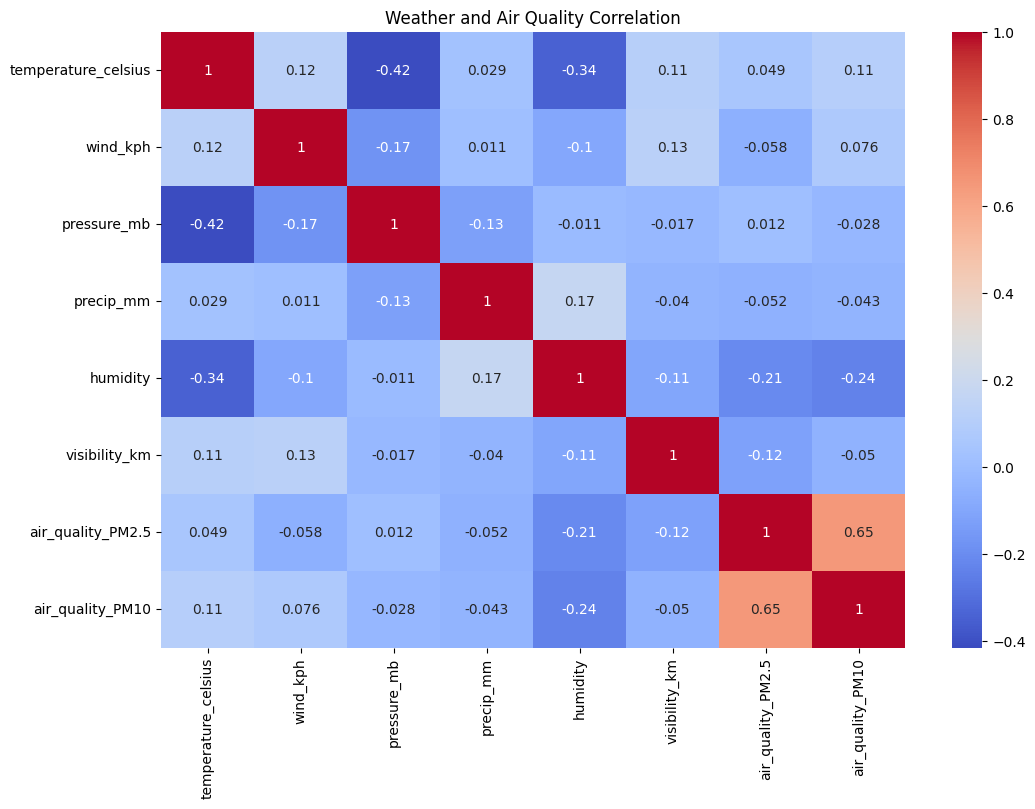

In [ ]:
## Polution based Correlation Analysis

corr_cols = [ "temperature_celsius","wind_kph", "pressure_mb","precip_mm",
              "humidity","visibility_km","air_quality_PM2.5","air_quality_PM10"]
plt.figure(figsize=(12, 8))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Weather and Air Quality Correlation")
plt.show()

## Insights
- PM2.5 and PM10 are highly correlated (0.97), as expected, indicating they move together.

- Temperature and pressure show a moderate negative correlation (-0.415); as temperature rises, pressure tends to fall.

- Humidity has a moderate positive correlation with PM2.5 (0.33) and PM10 (0.39), suggesting higher humidity might be linked to increased particulate matter.

- Visibility is negatively correlated with PM2.5 (-0.23) and PM10 (-0.28), meaning worse air quality leads to lower visibility.

- Wind_kph and precip_mm show relatively weak linear correlations with air quality in this dataset.

## Temperature vs PM2.5 Across Pollution Categories

- **Objective:** To analyze the relationship between temperature and PM2.5 levels across different pollution categories.
- **Attributes:** temperatue_celsius, air_quality_PM2.5 and Pollution_Category
- **Chart Type:** Scatter Plot
- **PLot Summary:** The scatter plot illustrates the relationship between temperature and PM2.5 levels across different pollution categories, highlighting variations in air quality at different temperature ranges.

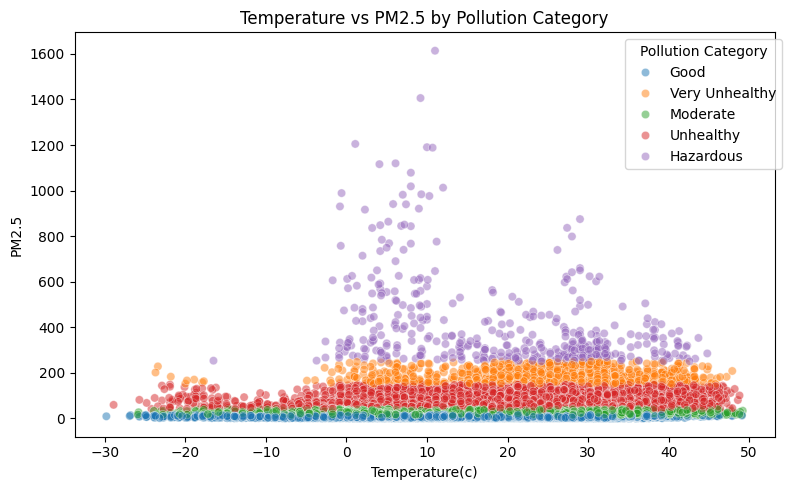

In [ ]:
## Temperature vs PM2.5 Across Pollution Categories

plt.figure(figsize=(8,5))

sns.scatterplot(x="temperature_celsius", y="air_quality_PM2.5",hue="pollution_category",data=df,alpha=0.5)
plt.title("Temperature vs PM2.5 by Pollution Category")
plt.xlabel("Temperature(c)")
plt.ylabel("PM2.5")

plt.legend(title="Pollution Category", bbox_to_anchor=(1.02,1),loc="upper right")
plt.tight_layout()
plt.show()

**Interpretation**

•	Good pollution observations are mainly concentrated at lower PM2.5 levels across most temperature ranges.

•	As PM2.5 increases, observations shift toward Moderate, Unhealthy, Very Unhealthy, and Hazardous categories.

•	The highest PM2.5 values are mostly observed around 0–15°C, with some extreme values exceeding 1,000 µg/m³.

•	At moderate-to-high temperatures (20–40°C), PM2.5 values are generally lower than the extreme concentrations seen around 0–15°C.

•	Overall, the plot shows variation in PM2.5 across temperature ranges, but temperature alone does not appear to consistently determine pollution levels.


## Hourly pattenrs in PM2.5 and PM10 pollution level

- **Objective:** To identify hourly patterns in PM2.5 and PM10 pollution levels.
- **Attribute:** update_hour, air_quality_PM2.5 and air_quality_PM10
- **Chart Type:** Line Chart
- **Plot Summary:** The line chart highlights hourly variations in PM2.5 and PM10 levels, helping identify periods of higher and lower pollution throughout the day.

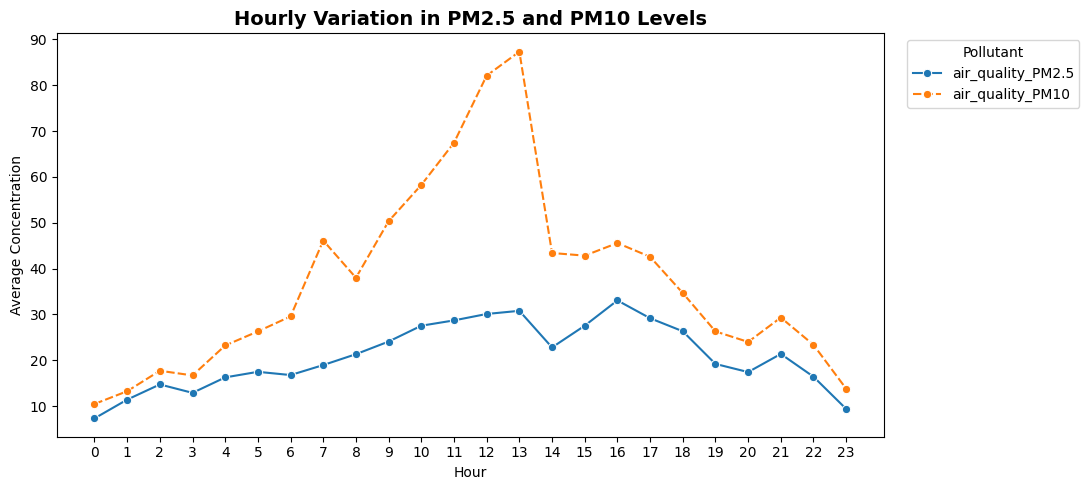

In [88]:
## Hourly Pattern

hour_pollution = (
    df.groupby("update_hour")[
        ["air_quality_PM2.5", "air_quality_PM10"]
    ].mean()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=hour_pollution,
    marker="o"
)

plt.title(
    "Hourly Variation in PM2.5 and PM10 Levels",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Hour")
plt.ylabel("Average Concentration")

plt.xticks(range(24))

plt.legend(
    title="Pollutant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Interpretation**

**Early Morning Peak (around 0-3 AM):** There's an initial peak in both PM2.5 and PM10 concentrations during the early morning hours, particularly around 1-3 AM.

**Morning Decline:** Following the early morning peak, pollution levels tend to decrease, reaching their lowest point in the late morning to early afternoon (roughly 6 AM to 12 PM).

**Afternoon/Evening Increase:** Both PM2.5 and PM10 levels begin to rise again in the afternoon, continuing into the evening.

**Evening Peak (around 6-9 PM):** Another significant peak in pollution is observed in the evening hours, typically between 6 PM and 9 PM.

**PM10 generally higher than PM2.5:** Throughout the day, PM10 concentrations are consistently higher than PM2.5 concentrations.

These patterns often correlate with human activity, such as morning and evening commutes, and atmospheric conditions like temperature inversions that can trap pollutants closer to the ground during specific times of the day.

##Key-Insights

📊 **Descriptive Analysis**

- The dataset covers weather and air-quality observations across multiple countries and cities, providing a global view of environmental conditions.
- Temperature observations are mainly concentrated around the 15°C–32°C range, while extreme temperatures occur less frequently.
- The analysis shows that Good and Moderate air-quality conditions are common, but unhealthy pollution categories are also present in several locations.
- PM10 is generally higher than PM2.5, indicating the presence of both fine and coarse particulate pollution.
- Country-wise analysis shows significant variation in average PM2.5 and PM10 concentrations.
- Higher PM2.5 concentrations are observed in some countries, indicating locations with comparatively poorer air quality.
- Wind speed and humidity show noticeable variation across observations, while extreme wind-speed values are relatively uncommon.


🔍 **Diagnostic Analysis**
- The Temperature vs PM2.5 analysis shows that PM2.5 occurs across a wide range of temperatures, suggesting that temperature alone does not explain pollution levels.
- The Wind Speed vs PM2.5 visualization indicates a possible negative relationship, where higher PM2.5 concentrations are more frequently observed at lower wind speeds.
- The Humidity vs PM2.5 analysis shows a possible positive relationship, with higher PM2.5 values occurring more frequently at higher humidity levels.
- Pollution categories show clear differences in PM2.5 concentration: Good and Moderate categories generally have lower PM2.5, while Unhealthy, Very Unhealthy and Hazardous categories have progressively higher values.
- Country-wise PM2.5 and PM10 averages indicate that geographical location is an important factor in pollution variation.
- Extreme values in variables such as wind speed and pollutant concentrations were identified as potential data errors or outliers and were reviewed during data cleaning.

💡 **Prescriptive Analysis**
- Locations showing consistently high PM2.5 and PM10 should be prioritized for air-quality monitoring and pollution-control measures.
- During periods of high pollution and low wind conditions, authorities can issue health advisories and recommend reducing outdoor exposure.
- Areas experiencing recurring unhealthy pollution levels can implement stronger emission-control strategies targeting traffic, industries and other pollution sources.
- Real-time monitoring can be used to provide early warnings when air quality approaches unhealthy levels.
- Weather conditions associated with higher pollution can be incorporated into an early-warning system for vulnerable populations.
- Countries and cities with comparatively cleaner air can be studied to identify better environmental practices.

🔮 **Predictive Analysis**
- Weather variables such as temperature, humidity, wind speed, cloud cover and visibility, together with pollutant measurements, can be used to predict future air-quality conditions.
- PM2.5 and PM10 levels can be used as important indicators for identifying the likelihood of higher pollution categories.
- Locations that repeatedly show high PM2.5/PM10 concentrations may have a higher likelihood of experiencing poor air-quality conditions.
- Historical weather and air-quality patterns can potentially be used to predict whether a location may fall into Good, Moderate, Unhealthy or Hazardous pollution categories.
- A machine-learning classification model could be developed to predict the US EPA pollution category using weather and pollutant features.

**Conclusion**

The Global Weather & Air Quality Analysis provides valuable insights into weather conditions and air-quality levels across different countries and cities. The analysis identified significant variations in temperature, humidity, wind speed, PM2.5, and PM10 concentrations across locations. The results also indicate that factors such as wind speed, humidity, temperature, and geographical location may influence air-quality conditions. Some locations showed higher particulate pollution and unhealthy air-quality categories, highlighting potential areas of concern. Overall, this analysis can support better air-quality monitoring, pollution assessment, early-warning systems, and data-driven environmental decision-making.